# Thesis figures Study 1

Notebook for the figures and tables cited in the thesis for Study 1

# Collider ML Data visualisation 

In [2]:
DATA_PATH = "./collider_data" 

# --- PHYSICS FILTERS ---
MAX_EVENTS = 50
MIN_PT_GEV = 1.0
MIN_HITS = 8
MAX_HITS = 20

In [3]:
# pdg look up table
PDG_NAMES = {
11: "Electron",
13: "Muon",
22: "Photon",
211: "Pion",
321: "Kaon",
2212: "Proton"
}

In [5]:
# # installs
# !pip install awkward pandas plotly colliderml

# # download data at {DATA_PATH} 
# !colliderml download --channels ttbar --pileup pu200 --objects particles,tracker_hits,tracks --max-events {MAX_EVENTS} --out {DATA_PATH}
# !pip install torch scikit-learn

In [6]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from colliderml.core import load_tables, collect_tables
from colliderml.polars import explode_particles, explode_tracker_hits

## Data Loading

In [ ]:
cfg = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu200", 
    "objects": ["particles", "tracker_hits", "tracks"],
    "split": "train",
    "lazy": True,
    "max_events": 50,
    "data_dir": DATA_PATH, 
}

print(f"Loading data from local folder: {DATA_PATH} ...")
tables = load_tables(cfg)
frames = collect_tables(tables)

Loading data from local folder: ./collider_data ...


## Number of hits histogram

Analyzing primary particle hits for the first 5 events.


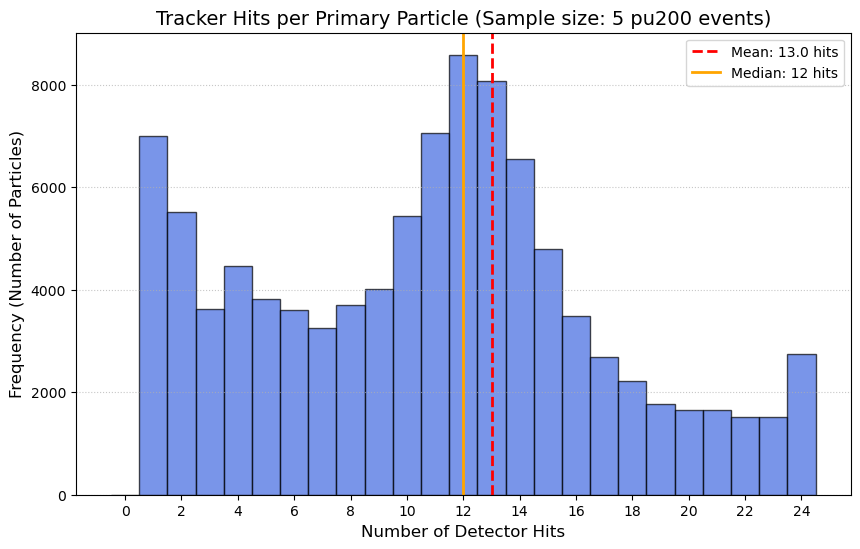

In [ ]:
def plot_primary_hits_histogram(frames, num_events=5):
    """
    Plots a histogram of the number of hits left by primary particles 
    across multiple events to help determine optimal filter ranges.
    """
    print(f"Analyzing primary particle hits for the first {num_events} events.")
    
    # 1. Grab a subset of event IDs to prevent RAM overload
    event_ids = frames["particles"]["event_id"].head(num_events).to_list()
    
    # Filter the tables to just those events
    p_evt = frames["particles"].filter(pl.col("event_id").is_in(event_ids))
    t_evt = frames["tracker_hits"].filter(pl.col("event_id").is_in(event_ids))
    
    # 2. Explode the tables
    particles_flat = explode_particles(p_evt)
    hits_flat = explode_tracker_hits(t_evt)
    
    # 3. Count hits per particle
    hit_counts = hits_flat['particle_id'].value_counts().rename('calculated_hits')
    
    # Merge the hit counts back into the particles table
    particles_flat = particles_flat.merge(hit_counts, left_on='particle_id', right_index=True, how='left')
    
    # Any particle that isn't in the hits table gets 0 hits
    particles_flat['calculated_hits'] = particles_flat['calculated_hits'].fillna(0)
    
    # 4. Filter for Primary particles only
    mask_primary = particles_flat.get('primary', True) == True
    primary_particles = particles_flat[mask_primary]
    
    # Extract just the hit array
    hits_data = primary_particles['calculated_hits']
    #  Remove invisible particles ---
    clean_hits_data = hits_data[hits_data > 0]
    
    # 5. Plot the Histogram
    plt.figure(figsize=(10, 6))
    
    # Define bins from 0 to 25
    bins = np.arange(0, 26, 1)
    
    # The align='left' makes sure the bar sits directly over the integer on the x-axis
    plt.hist(clean_hits_data, bins=bins, color='royalblue', edgecolor='black', alpha=0.7, align='left')
    
    # Formatting
    plt.title(f'Tracker Hits per Primary Particle (Sample size: {num_events} pu200 events)', fontsize=14)
    plt.xlabel('Number of Detector Hits', fontsize=12)
    plt.ylabel('Frequency (Number of Particles)', fontsize=12)
    plt.xticks(np.arange(0, 26, 2))
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    
    # Add Mean and Median lines for easy reading
    mean_hits = clean_hits_data.mean()
    median_hits = clean_hits_data.median()
    
    plt.axvline(mean_hits, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_hits:.1f} hits')
    plt.axvline(median_hits, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_hits:.0f} hits')
    
    plt.legend()
    plt.show()

# Run the function!
plot_primary_hits_histogram(frames, num_events=5)

## Math and Plotting functions

In [ ]:
def generate_helix_points(d0, z0, phi, theta, qop, sT_max, B_field=-2.0, steps=200):
    """Draws a helix using the official ACTS Perigee Parameterization."""
    R = (np.sin(theta) / (0.3 * B_field * qop)) * 1000
    s_T = np.linspace(0, sT_max, steps)
    
    x0 = -d0 * np.sin(phi)
    y0 = d0 * np.cos(phi)
    
    x = x0 + R * (np.sin(phi + s_T / R) - np.sin(phi))
    y = y0 - R * (np.cos(phi + s_T / R) - np.cos(phi))
    z = z0 + s_T * (np.cos(theta) / np.sin(theta))
    return x, y, z

In [ ]:
def extract_track_data(frames, event_id, target_particle_id):
    """Helper to extract hits, true parameters, and fitted parameters safely."""
    # 1. Extract Hits
    tracker_evt = frames["tracker_hits"].filter(pl.col("event_id") == event_id)
    particle_hits = explode_tracker_hits(tracker_evt).query(f"particle_id == {target_particle_id}")
    
    # 2. Extract True Parameters
    particles_evt = frames["particles"].filter(pl.col("event_id") == event_id)
    true_data = explode_particles(particles_evt).query(f"particle_id == {target_particle_id}").iloc[0]
    
    p = np.sqrt(true_data["px"]**2 + true_data["py"]**2 + true_data["pz"]**2)
    truth = {
        "d0": true_data["perigee_d0"],
        "z0": true_data["perigee_z0"],
        "phi": np.arctan2(true_data["py"], true_data["px"]),
        "theta": np.arccos(true_data["pz"] / p),
        "qop": true_data["charge"] / p,
        "pdg_id": int(true_data["pdg_id"])
    }
    
    # 3. Extract Fitted Parameters (ACTS Kalman Filter)
    tracks_evt = frames["tracks"].filter(pl.col("event_id") == event_id)
    tracks_flat = tracks_evt.explode(["track_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"]).to_pandas()
    fitted_candidates = tracks_flat[tracks_flat["majority_particle_id"] == target_particle_id]
    fitted = fitted_candidates.iloc[0] if not fitted_candidates.empty else None
    
    return particle_hits, truth, fitted

In [ ]:
def plot_track_comparison(frames, event_id, target_particle_id, mode="3d"):
    """
    Plots the true track, fitted track, and raw hits.
    Modes available: "3d", "xy" (Transverse), "rz" (Longitudinal)
    """
    hits, truth, fitted = extract_track_data(frames, event_id, target_particle_id)
    
    hits_x, hits_y, hits_z = hits["x"].to_numpy(), hits["y"].to_numpy(), hits["z"].to_numpy()
    
    # Calculate R for both the sT_max boundary and the R-Z plot
    hits_r = np.sqrt(hits_x**2 + hits_y**2)
    sT_max = np.max(hits_r) * 1.1

    # --- Setup the Figure based on mode ---
    if mode == "rz":
        fig = plt.figure(figsize=(12, 6)) # Wider figure for longitudinal
        ax = fig.add_subplot(111)
    elif mode == "xy":
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111)
    else: # Default to 3D
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

    # --- Plot Truth Line (Green) ---
    true_x, true_y, true_z = generate_helix_points(
        d0=truth["d0"], z0=truth["z0"], phi=truth["phi"], 
        theta=truth["theta"], qop=truth["qop"], sT_max=sT_max
    )
    true_r = np.sqrt(true_x**2 + true_y**2)
        
    # --- Plot Fitted Line (Red) ---
    if fitted is not None:
        fit_x, fit_y, fit_z = generate_helix_points(
            d0=fitted["d0"], z0=fitted["z0"], phi=fitted["phi"], 
            theta=fitted["theta"], qop=fitted["qop"], sT_max=sT_max
        )
        fit_r = np.sqrt(fit_x**2 + fit_y**2)

    # --- Mode-Specific Plotting ---
    if mode == "3d":
        ax.scatter(hits_x, hits_y, hits_z, c='black', marker='o', s=50, label='Detector Hits', zorder=3)
        ax.plot(true_x, true_y, true_z, c='lime', linewidth=8, alpha=0.6, label='True Track', zorder=1)
        if fitted is not None:
            ax.plot(fit_x, fit_y, fit_z, c='red', linewidth=2, linestyle='--', label='Fitted Track (ACTS)', zorder=2)
        ax.set_xlabel('X position (mm)')
        ax.set_ylabel('Y position (mm)')
        ax.set_zlabel('Z position (mm) [Beamline]')
        title_prefix = "3D Projection"

    elif mode == "xy":
        ax.add_patch(plt.Circle((0, 0), 1000, fill=False, color='lightgray', linestyle='--', linewidth=2, label='Detector'))
        ax.scatter(hits_x, hits_y, c='black', marker='o', s=60, label='Detector Hits', zorder=3)
        ax.plot(true_x, true_y, c='lime', linewidth=6, alpha=0.5, label='True Track', zorder=1)
        if fitted is not None:
            ax.plot(fit_x, fit_y, c='red', linewidth=2, linestyle='--', label='Fitted Track (ACTS)', zorder=2)
        ax.set_aspect('equal')
        ax.set_xlim(-1100, 1100)
        ax.set_ylim(-1100, 1100)
        ax.set_xlabel('X position (mm)')
        ax.set_ylabel('Y position (mm)')
        title_prefix = "2D Transverse (X-Y) Projection"
        
    elif mode == "rz":
        import matplotlib.patches as patches
        ax.add_patch(patches.Rectangle((-1500, 0), 3000, 1000, linewidth=2, edgecolor='lightgray', facecolor='none', linestyle='--', label='Detector Boundary'))
        ax.scatter(hits_z, hits_r, c='black', marker='o', s=60, label='Detector Hits', zorder=3)
        ax.plot(true_z, true_r, c='lime', linewidth=6, alpha=0.5, label='True Track', zorder=1)
        if fitted is not None:
            ax.plot(fit_z, fit_r, c='red', linewidth=2, linestyle='--', label='Fitted Track (ACTS)', zorder=2)
        ax.set_xlim(-1600, 1600)
        ax.set_ylim(0, 1100)
        ax.set_xlabel('Z position (mm) [Along Beamline]')
        ax.set_ylabel('R position (mm) [Distance from Beam]')
        title_prefix = "2D Longitudinal (R-Z) Projection"

    if fitted is None:
        print(f"\n⚠️ WARNING: ACTS failed to reconstruct Particle {target_particle_id}!")
    
    pdg_id = truth["pdg_id"]
    particle_name = PDG_NAMES.get(abs(pdg_id), "Unknown")
    
    ax.set_title(f'{title_prefix} | Event {event_id} | Particle {target_particle_id} ({particle_name}, PDG: {pdg_id})')
    
    # Legend handling (moves legend outside the plot for 2D views so it doesn't cover tracks)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0) if mode != "3d" else None)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

## Filtering and plotting


Processing Event ID: 0...
Target Particle ID: 517
Tracker hits: 14 | pT: 39.44 GeV


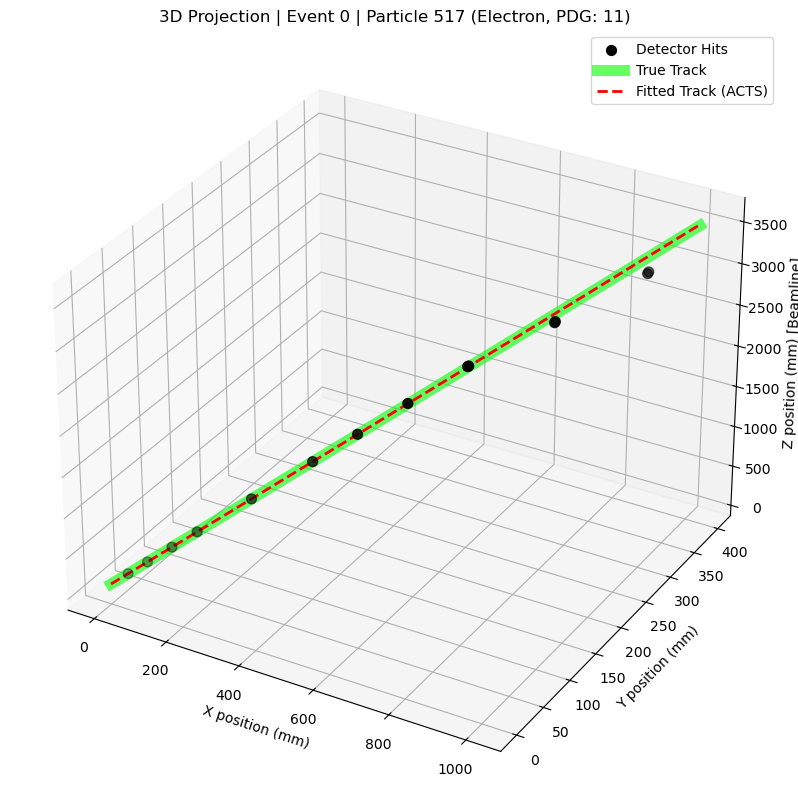

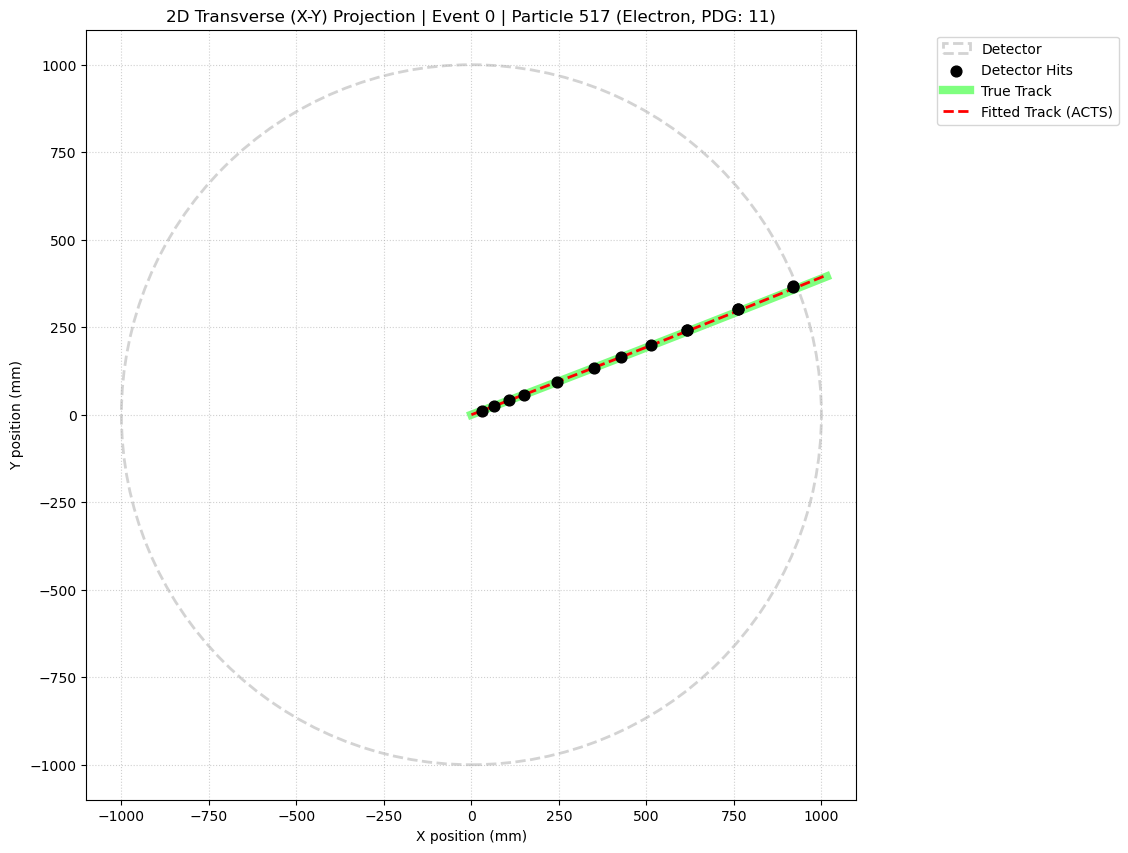

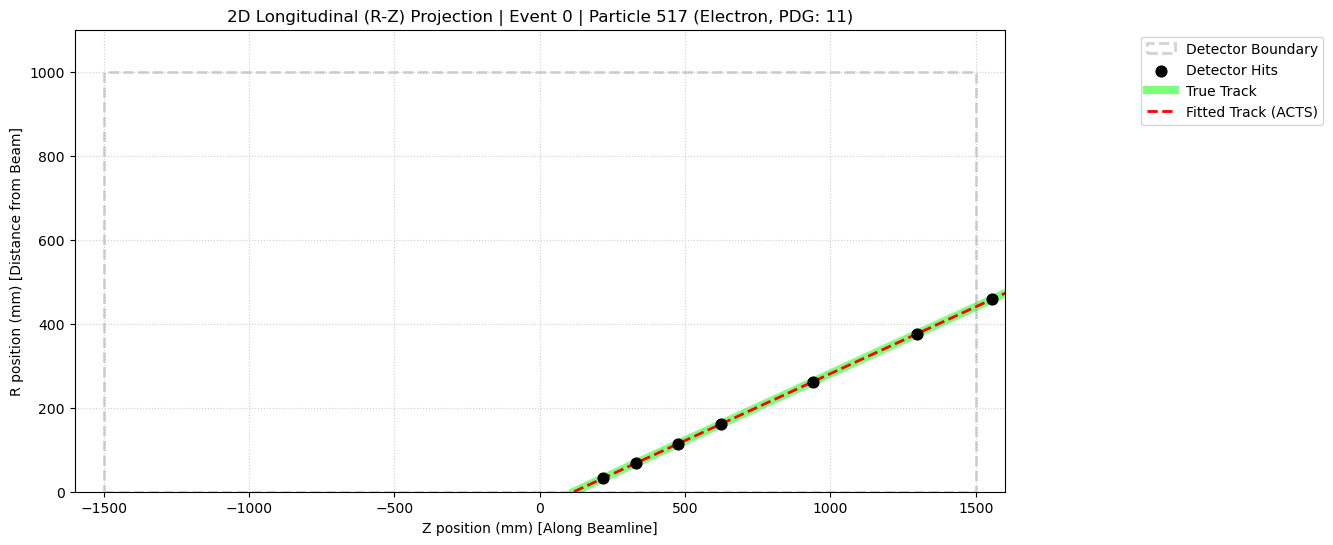

In [ ]:
# 1. Get the first event and explode tables
event_id = frames["particles"]["event_id"][0]
print(f"\nProcessing Event ID: {event_id}...")

particles_flat = explode_particles(frames["particles"].filter(pl.col("event_id") == event_id))
hits_flat = explode_tracker_hits(frames["tracker_hits"].filter(pl.col("event_id") == event_id))

# 2. Count hits, calculate pT, and merge into particles table
hit_counts = hits_flat['particle_id'].value_counts().rename('calculated_hits')
particles_flat = particles_flat.merge(hit_counts, left_on='particle_id', right_index=True, how='left')
particles_flat["pt"] = np.sqrt(particles_flat["px"]**2 + particles_flat["py"]**2)

# 3. Apply the Configurable Filters (using parameters from Step 1)
mask_primary = particles_flat.get('primary', True) == True
mask_pt      = particles_flat["pt"] > MIN_PT_GEV
mask_hits    = (particles_flat['calculated_hits'].fillna(0) >= MIN_HITS) & \
               (particles_flat['calculated_hits'].fillna(0) <= MAX_HITS)

good_particles = particles_flat[mask_primary & mask_pt & mask_hits].copy()
good_particles = good_particles.sort_values(by="pt", ascending=False)

if good_particles.empty:
    print("No particles found matching your filter criteria in this event.")
else:
    # 4. Select target and Plot!
    particle_index = 0
    target_particle_id = good_particles.iloc[particle_index]["particle_id"]
    print(f"Target Particle ID: {target_particle_id}")
    print(f"Tracker hits: {int(good_particles.iloc[particle_index]['calculated_hits'])} | pT: {good_particles.iloc[particle_index]['pt']:.2f} GeV")
    
    # Plot all three views for your target particle!
    plot_track_comparison(frames, event_id, target_particle_id, mode="3d")
    plot_track_comparison(frames, event_id, target_particle_id, mode="xy")
    plot_track_comparison(frames, event_id, target_particle_id, mode="rz")

# Model training results

In [9]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown, IFrame

# Path to data/plots 
BASE_DIR = Path.home() / "Macbook/UCL_MSc_ML/MSc Thesis/notebooks/ParamRegressionResults/Data"

PARAM_NAMES = ["d0", "z0", "phi", "theta", "qop"]

# ============================================================
# Experiment 1 (Sec. 4.2 / tab:tf_headmode): shared vs.
# Separaten head, 3 seeds each (v3_150ep_fixed
# pipeline)
# ============================================================
HEADMODE_RUNS = {
    "shared_s0":    BASE_DIR / "exp2_head_shared_v3_150ep_fixed_seed0",
    "shared_s1":    BASE_DIR / "exp2_head_shared_v3_150ep_fixed_seed1",
    "shared_s2":    BASE_DIR / "exp2_head_shared_v3_150ep_fixed_seed2",
    "separate_s0":  BASE_DIR / "exp2_head_separate_v3_150ep_fixed_seed0",
    "separate_s1":  BASE_DIR / "exp2_head_separate_v3_150ep_fixed_seed1",
    "separate_s2":  BASE_DIR / "exp2_head_separate_v3_150ep_fixed_seed2",
}

# ============================================================
# Experiment 2 (Sec. 4.2 / tab:tf_posenc): positional-encoding
# ablation, single seed each
# ============================================================
POSENC_RUNS = {
    "none":       BASE_DIR / "exp1_fixed_posenc_none_seed0",
    "sinusoidal": BASE_DIR / "exp1_fixed_posenc_sinusoidal_seed0",
    "learnable":  BASE_DIR / "exp1_fixed_posenc_learnable_seed0",
}

# ============================================================
# Experiment 3 (Sec. 4.2 / tab:tf_scaling): model-size scaling.
# ============================================================
SCALING_RUNS = {
    "d32":  BASE_DIR / "exp9_scale_model_d32_noposenc",
    "d64":  BASE_DIR / "exp9_scale_model_d64_noposenc",
    "d96":  BASE_DIR / "exp9_scale_model_d96_noposenc",
    "d128": BASE_DIR / "exp9_scale_model_d128_noposenc",
    "d192_corrected": BASE_DIR / "exp9b_scale_model_d192_L10_lrfix_noposenc",
    "d256_corrected": BASE_DIR / "exp9b_scale_model_d256_L12_lrfix_noposenc",
}

# ============================================================
# Experiment 4 (Sec. 4.2 / tab:tf_acts, fig:tf_ml_vs_acts):
# ML vs. ACTS comparison. Best configuration overall = d192
# (corrected)
# ============================================================
BEST_RUN = BASE_DIR / "exp9b_scale_model_d192_L10_lrfix_noposenc"

ALL_RUN_GROUPS = {
    "Experiment 1 (head mode)": HEADMODE_RUNS,
    "Experiment 2 (positional encoding)": POSENC_RUNS,
    "Experiment 3 (model scaling)": SCALING_RUNS,
    "Best/ACTS-comparison run": {"best": BEST_RUN},
}

missing = {}
for group_name, runs in ALL_RUN_GROUPS.items():
    for name, path in runs.items():
        if not path.exists():
            missing.setdefault(group_name, {})[name] = str(path)

if missing:
    print("WARNING - these run folders were not found (check BASE_DIR / scp step):")
    for group_name, runs in missing.items():
        print(f"  {group_name}:")
        for name, path in runs.items():
            print(f"    {name}: {path}")
else:
    n_total = sum(len(v) for v in ALL_RUN_GROUPS.values())
    print(f"All {n_total} run folders found under {BASE_DIR}")


All 16 run folders found under /Users/meghnachoudhary/Macbook/UCL_MSc_ML/MSc Thesis/notebooks/ParamRegressionResults/Data


## Experiment 1: Regression Head Comparison

In [ ]:
# Resolution per seed for both head configurations, straight from test_resolutions.json
def load_resolutions(run_dir):
    """Read a run's Separate test resolution."""
    path = run_dir / "test_resolutions.json"
    if not path.exists():
        return {p: None for p in PARAM_NAMES}
    with open(path) as f:
        return json.load(f)

headmode_rows = {name: load_resolutions(d) for name, d in HEADMODE_RUNS.items()}
headmode_df = pd.DataFrame(headmode_rows).T
headmode_df.index.name = "run"

print("Per-seed resolution, shared vs. Separate head (3 seeds each):")
headmode_df.style.format("{:.5f}")


,d0,z0,phi,theta,qop
run,,,,,
shared_s0,0.02127,2.34216,0.00191,0.00563,0.03590
shared_s1,0.01423,0.80482,0.00075,0.00088,0.00773
shared_s2,0.01466,1.01885,0.00073,0.00091,0.00669
separate_s0,0.01659,1.55653,0.00097,0.00167,0.00991
separate_s1,0.01517,1.61344,0.00083,0.00145,0.00826
separate_s2,0.01523,1.23449,0.00084,0.00162,0.00802


In [29]:
# Exclude any seed whose val loss is more than 2x the median of the others
# (this is the criterion described in the thesis text for the shared-head outlier)
FACTOR_THRESHOLD = 2.0

def load_val_loss(run_dir):
    """Read a run's best validation loss."""
    path = run_dir / "run_summary.json"
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f).get("best_val_loss")

def usable_seeds(seed_names, run_lookup):
    """Split seeds into usable/excluded based on the factor-of-2 val loss rule."""
    losses = {name: load_val_loss(run_lookup[name]) for name in seed_names}
    usable, excluded = [], []
    for name, loss in losses.items():
        median_others = np.median([l for n, l in losses.items() if n != name])
        (usable if loss is not None and loss <= FACTOR_THRESHOLD * median_others else excluded).append(name)
    return usable, excluded, losses

shared_seeds = ["shared_s0", "shared_s1", "shared_s2"]
separate_seeds = ["separate_s0", "separate_s1", "separate_s2"]

shared_usable, shared_excluded, shared_losses = usable_seeds(shared_seeds, HEADMODE_RUNS)
separate_usable, separate_excluded, separate_losses = usable_seeds(separate_seeds, HEADMODE_RUNS)

print(f"Shared head: usable seeds = {shared_usable}, excluded = {shared_excluded}")
print(f"Separate head: usable seeds = {separate_usable}, excluded = {separate_excluded}")

# Median and std of resolution over the usable seeds only, per parameter
summary_rows = {}
for label, usable in [("Shared", shared_usable), ("Separate", separate_usable)]:
    vals = {p: [headmode_rows[name][p] for name in usable] for p in PARAM_NAMES}
    summary_rows[(label, "median")] = {p: np.median(vals[p]) for p in PARAM_NAMES}
    summary_rows[(label, "std")] = {p: np.std(vals[p]) for p in PARAM_NAMES}

summary_df = pd.DataFrame(summary_rows).T
print("\nMedian and std resolution over usable seeds:")
summary_df.style.format("{:.5f}")


Shared head: usable seeds = ['shared_s1', 'shared_s2'], excluded = ['shared_s0']
Separate head: usable seeds = ['separate_s0', 'separate_s1', 'separate_s2'], excluded = []

Median and std resolution over usable seeds:


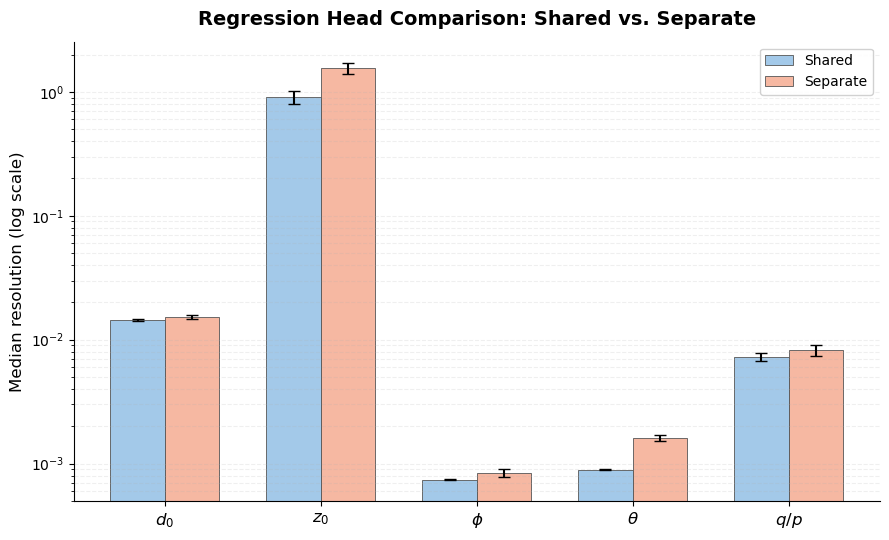

In [33]:
# Median resolution across all five parameters, shared vs. Separate head, one figure
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(PARAM_NAMES))
width = 0.35
colors = {"Shared": "#a3c9e9", "Separate": "#f6b8a2"}  # sky blue / salmon

for i, label in enumerate(["Shared", "Separate"]):
    medians = [summary_rows[(label, "median")][p] for p in PARAM_NAMES]
    stds = [summary_rows[(label, "std")][p] for p in PARAM_NAMES]
    offset = (i - 0.5) * width
    ax.bar(x + offset, medians, width, yerr=stds, capsize=4, label=label,
           color=colors[label], edgecolor="#555555", linewidth=0.6)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([r"$d_0$", r"$z_0$", r"$\phi$", r"$\theta$", r"$q/p$"], fontsize=12)
ax.set_ylabel("Median resolution (log scale)", fontsize=12)
ax.set_title("Regression Head Comparison: Shared vs. Separate", fontsize=14, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="y", which="both", linestyle="--", alpha=0.2)
ax.legend(frameon=True, framealpha=0.9, edgecolor="#cccccc")
fig.tight_layout()
plt.show()


## Exp 2: Pos enc ablation

In [ ]:
# Single-seed resolution for each positional-encoding scheme
posenc_rows = {name: load_resolutions(d) for name, d in POSENC_RUNS.items()}
posenc_df = pd.DataFrame(posenc_rows).T
posenc_df.index.name = "run"

print("Resolution by positional-encoding scheme (single seed each):")
print("Sinusoidal collapsed early in training - see run_summary.json best_epoch.")
posenc_df.style.format("{:.5f}")


Resolution by positional-encoding scheme (single seed each):
Sinusoidal collapsed early in training - see run_summary.json best_epoch below.


,d0,z0,phi,theta,qop
run,,,,,
none,0.01417,0.56313,0.00073,0.00093,0.00474
sinusoidal,0.02176,2.18709,0.00228,0.00276,0.07597
learnable,0.01396,0.56280,0.00073,0.00098,0.00464


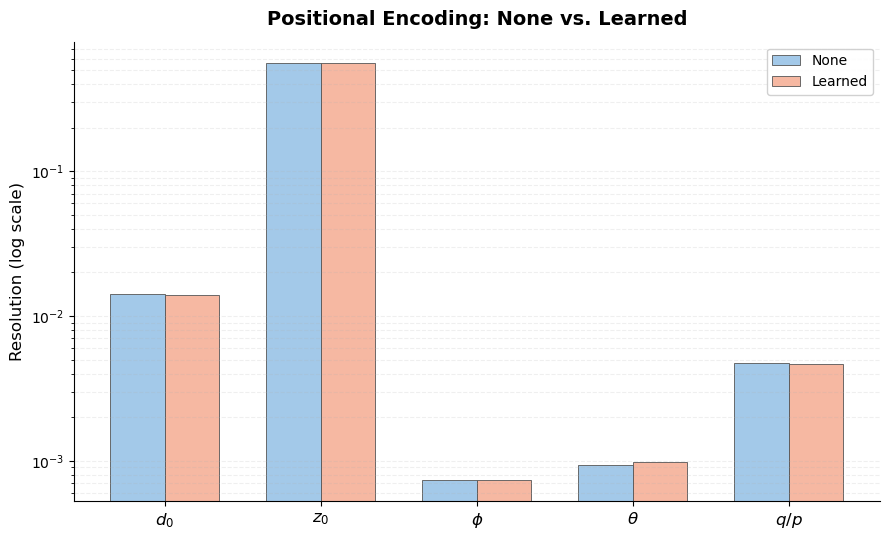

In [35]:
# None vs. learned only -- sinusoidal excluded, collapsed to a different scale entirely
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(PARAM_NAMES))
width = 0.35
colors = {"None": "#a3c9e9", "Learned": "#f6b8a2"}

for i, label, run_name in [(0, "None", "none"), (1, "Learned", "learnable")]:
    vals = [posenc_rows[run_name][p] for p in PARAM_NAMES]
    offset = (i - 0.5) * width
    ax.bar(x + offset, vals, width, label=label, color=colors[label], edgecolor="#555555", linewidth=0.6)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([r"$d_0$", r"$z_0$", r"$\phi$", r"$\theta$", r"$q/p$"], fontsize=12)
ax.set_ylabel("Resolution (log scale)", fontsize=12)
ax.set_title("Positional Encoding: None vs. Learned", fontsize=14, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="y", which="both", linestyle="--", alpha=0.2)
ax.legend(frameon=True, framealpha=0.9, edgecolor="#cccccc")
fig.tight_layout()
plt.show()


### Loss curves

**none**

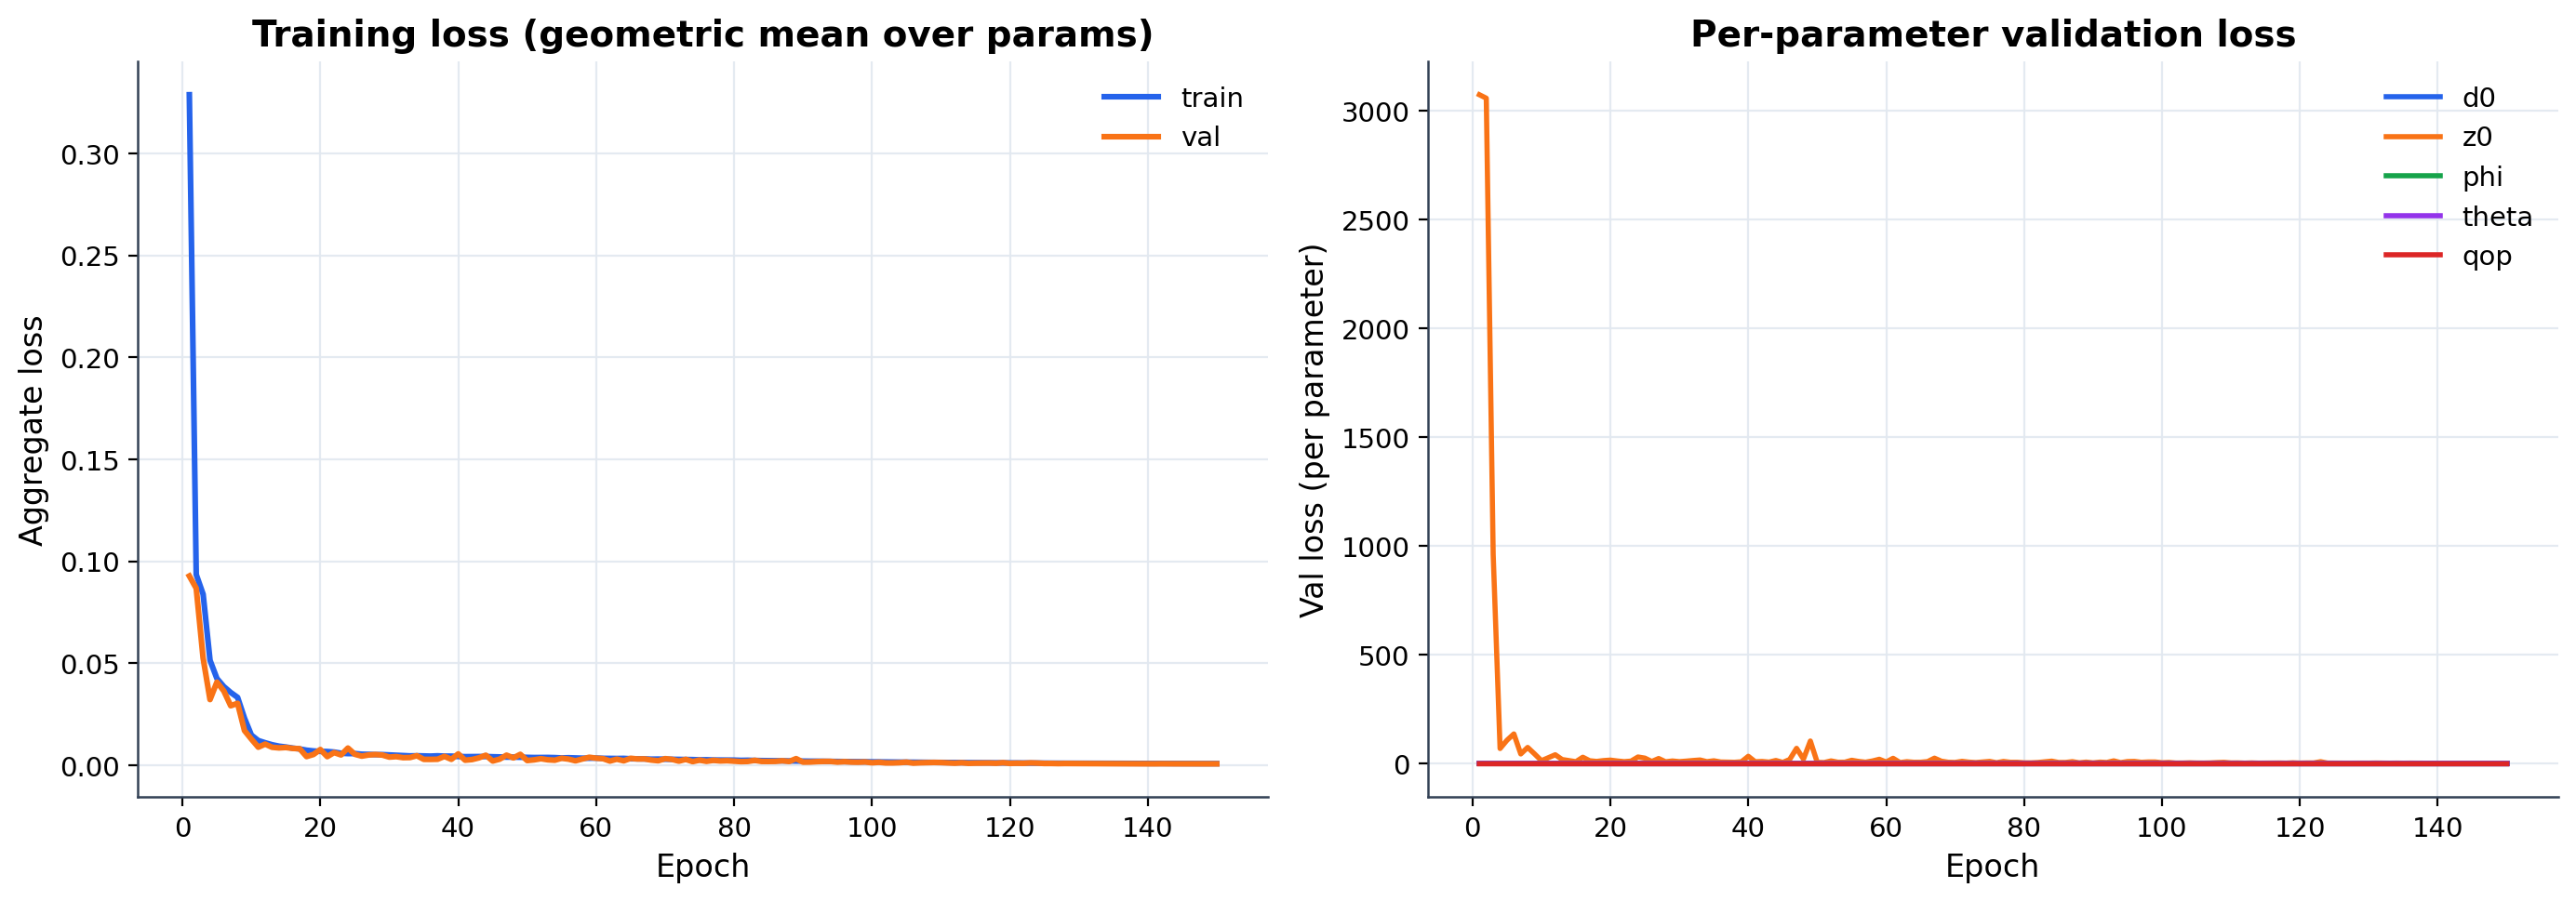

**sinusoidal**

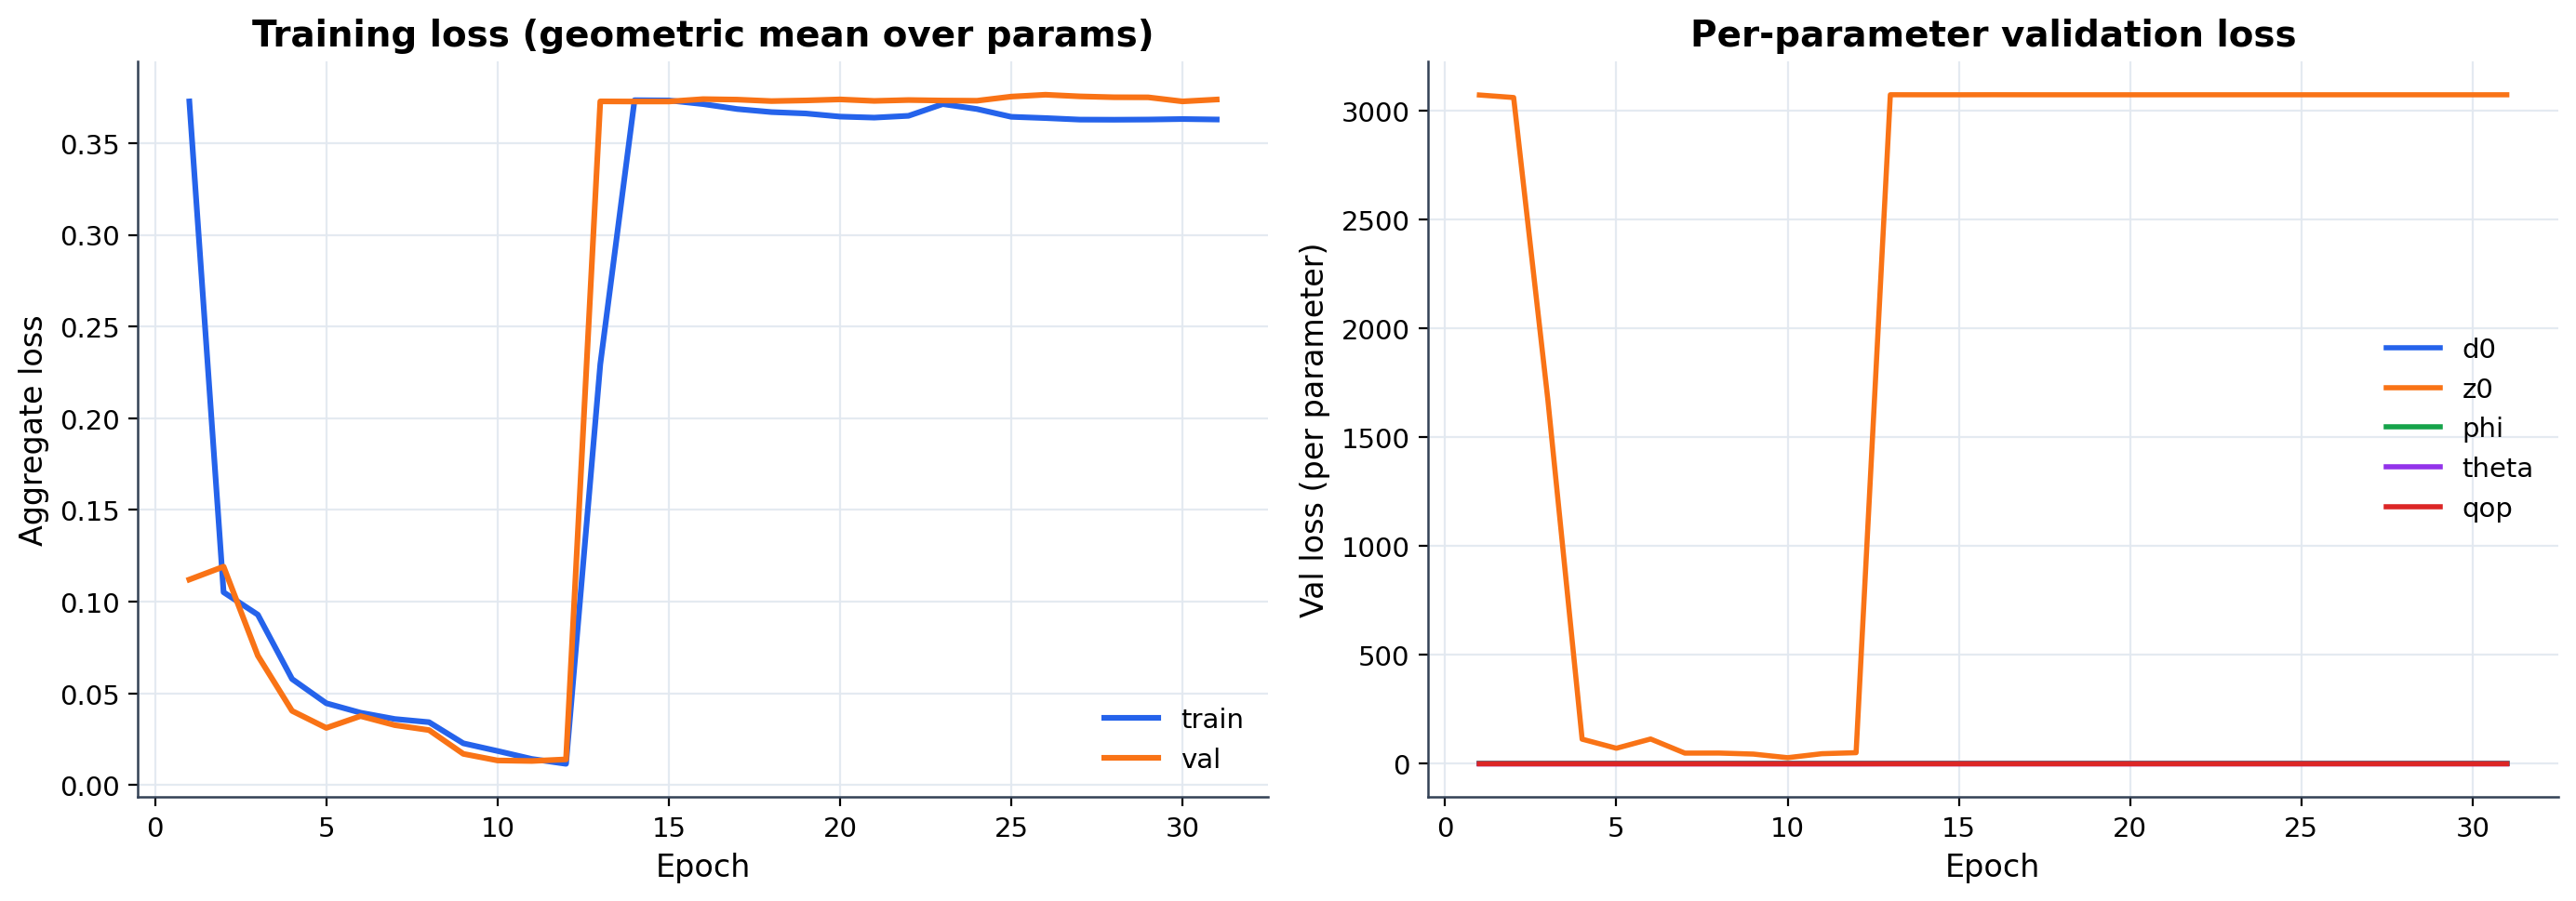

**learnable**

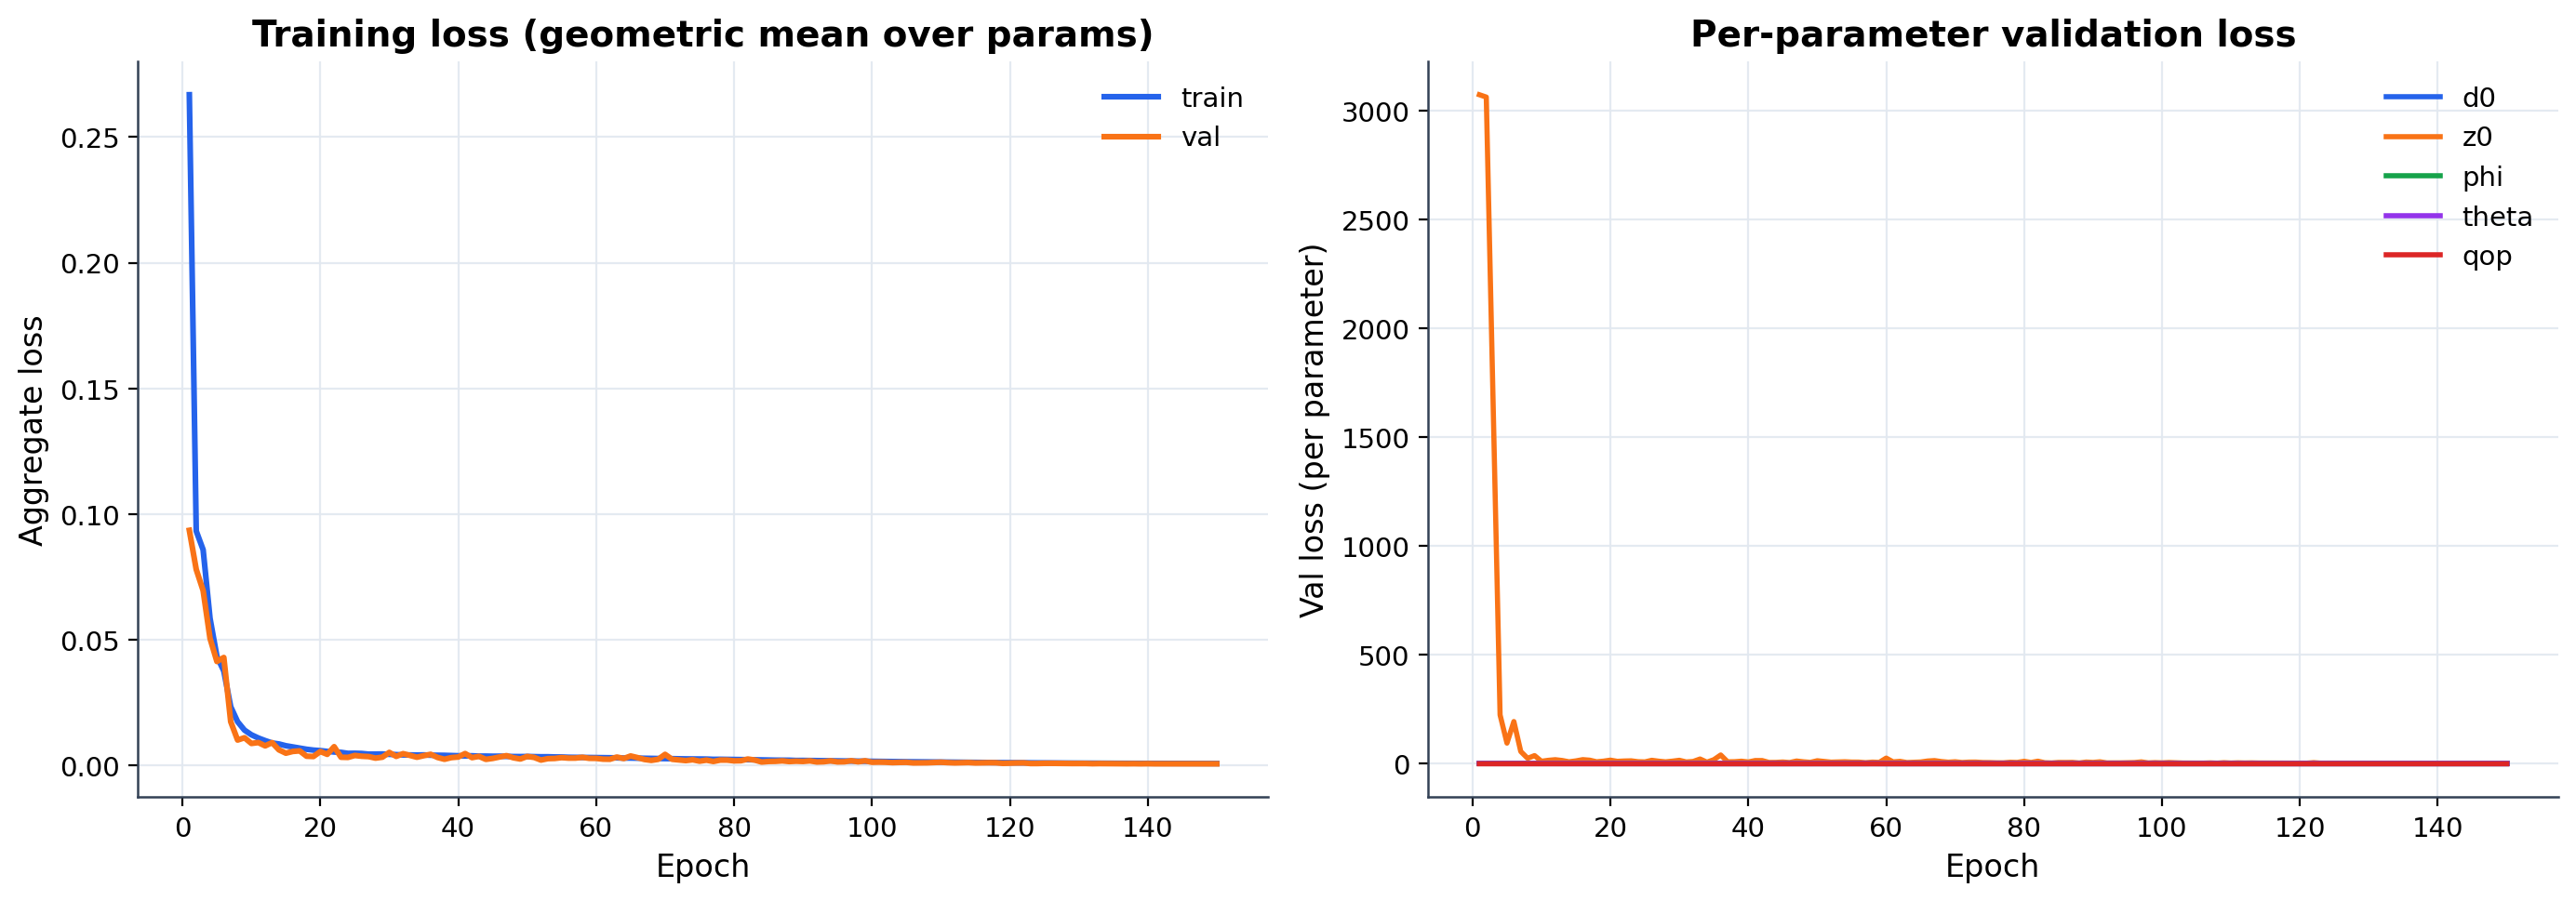

In [36]:
# Training/validation loss curves for all three encoding schemes
for name, run_dir in POSENC_RUNS.items():
    plot_path = run_dir / "plot_loss_curve.png"
    display(Markdown(f"**{name}**"))
    if plot_path.exists():
        display(Image(filename=str(plot_path), width=650))
    else:
        print(f"  (missing: {plot_path})")


### Prediction vs. truth heatmaps

**none**

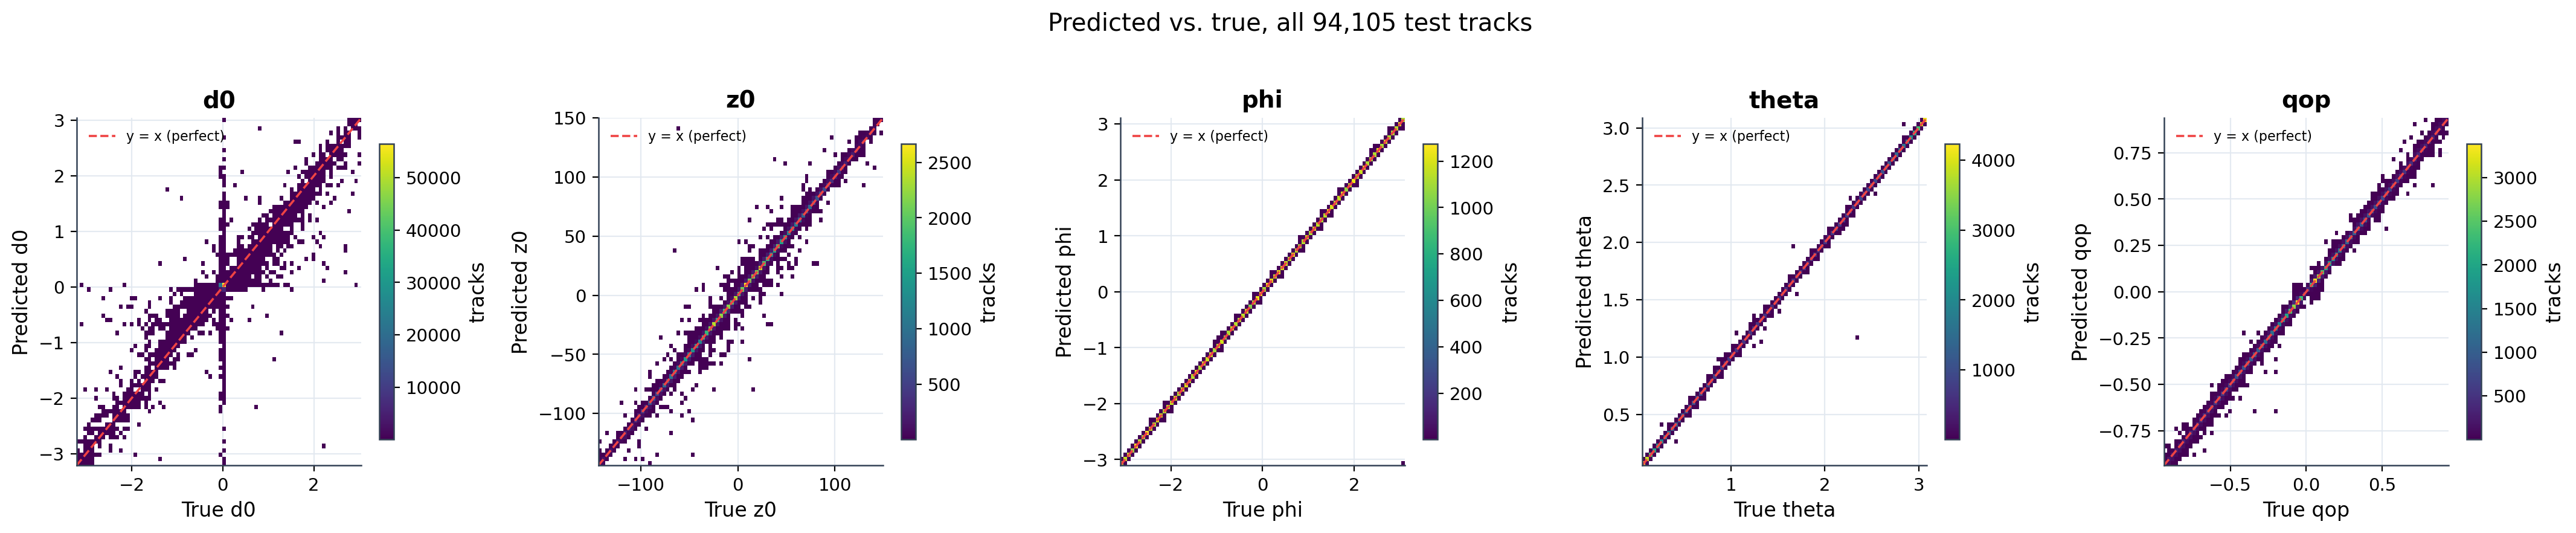

**sinusoidal**

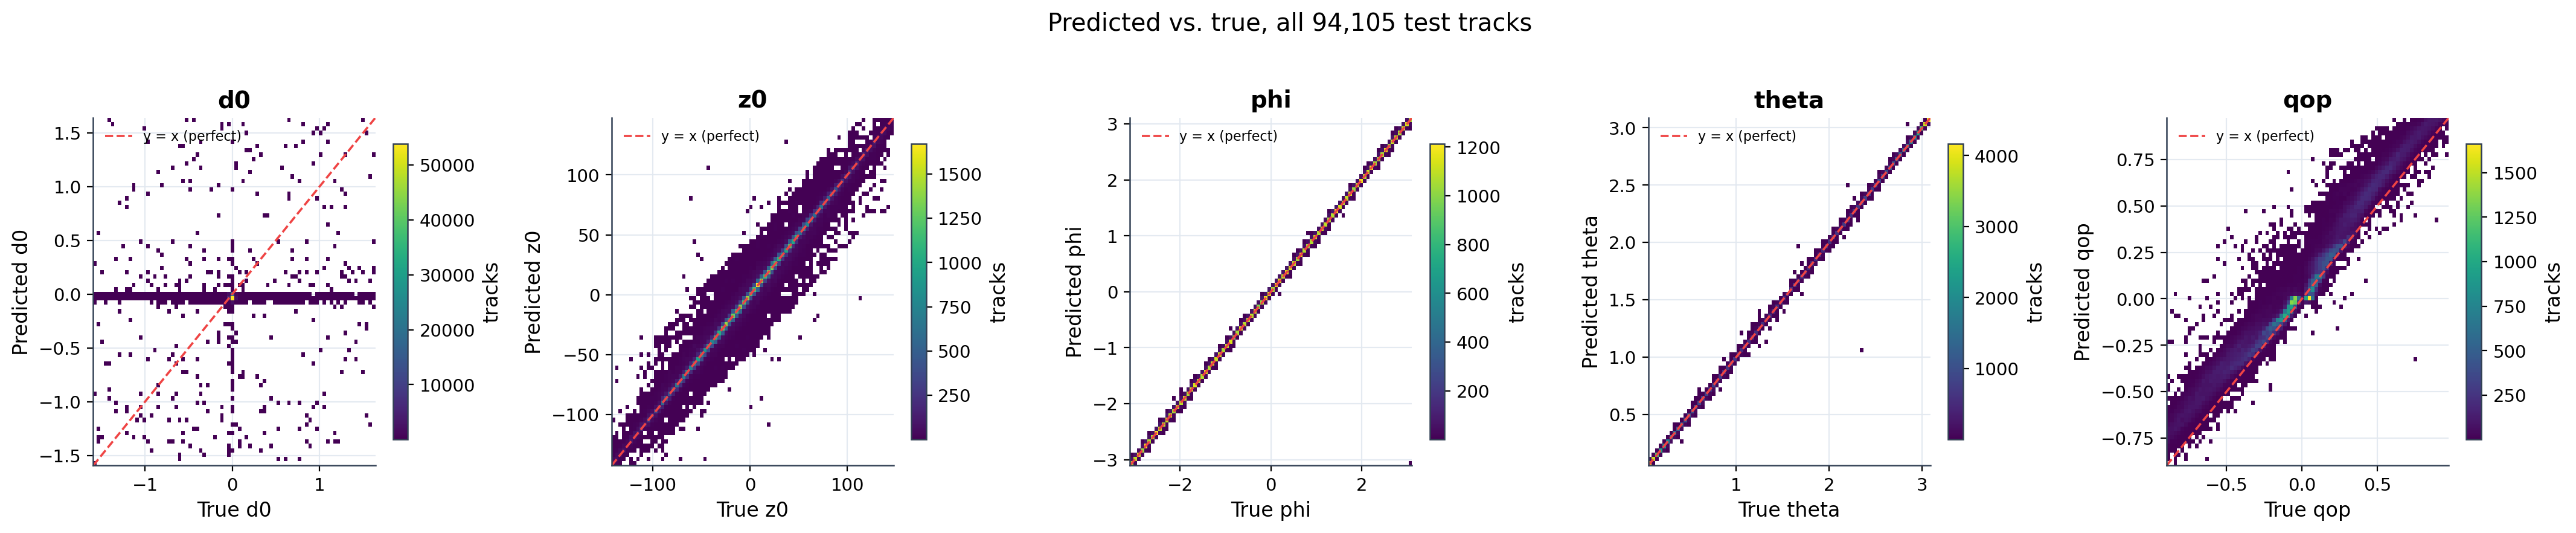

**learnable**

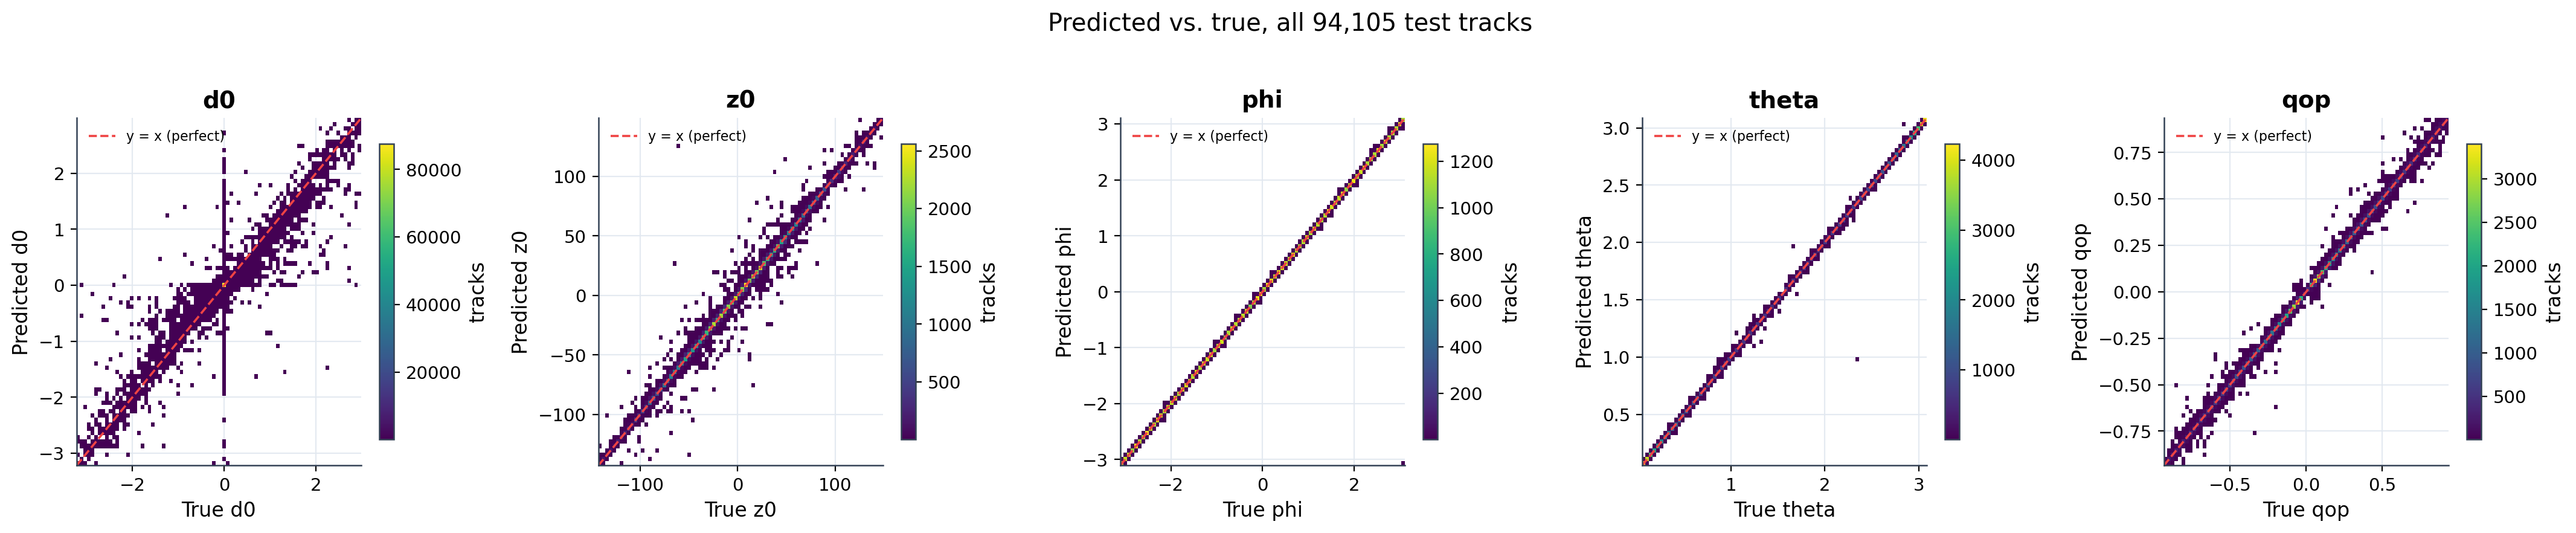

In [134]:
# Prediction vs. truth density heatmaps (all five parameters), one per encoding scheme
for name, run_dir in POSENC_RUNS.items():
    plot_path = run_dir / "plot_pred_vs_true.png"
    display(Markdown(f"**{name}**"))
    if plot_path.exists():
        display(Image(filename=str(plot_path), width=1000))
    else:
        print(f"  (missing: {plot_path})")


## Exp 3: Model scaling

In [40]:
# Config, depth, peak LR, and resolution for each scaling point.
# Only the locally-synced runs are shown here -- the original collapsed
# d192-d384 sweep and the width-only (L8) diagnostic reruns quoted in the
# thesis table aren't synced as run folders, only as hardcoded numbers.
def load_config(run_dir):
    path = run_dir / "config.json"
    with open(path) as f:
        return json.load(f)

scaling_rows = {}
for name, run_dir in SCALING_RUNS.items():
    cfg = load_config(run_dir)
    row = {"num_layers": cfg.get("num_layers"), "peak_lr": cfg.get("lr")}
    row.update(load_resolutions(run_dir))
    scaling_rows[name] = row

scaling_df = pd.DataFrame(scaling_rows).T
scaling_df.index.name = "config"
print("Model-scaling sweep: architecture, LR, and resolution per config.")
scaling_df.style.format({"num_layers": "{:.0f}", "peak_lr": "{:.0e}", **{p: "{:.5f}" for p in PARAM_NAMES}})


Model-scaling sweep: architecture, LR, and resolution per config.


,num_layers,peak_lr,d0,z0,phi,theta,qop
config,,,,,,,
d32,2,1e-03,0.01717,1.30993,0.00127,0.00209,0.01061
d64,4,1e-03,0.01443,0.44557,0.00073,0.00105,0.00495
d96,6,1e-03,0.01427,0.52124,0.00076,0.00099,0.00509
d128,8,1e-03,0.01404,0.56153,0.00072,0.00105,0.00493
d192_corrected,10,2e-04,0.01365,0.34295,0.00066,0.00079,0.00390
d256_corrected,12,1e-04,0.01380,0.35161,0.00068,0.00073,0.00438


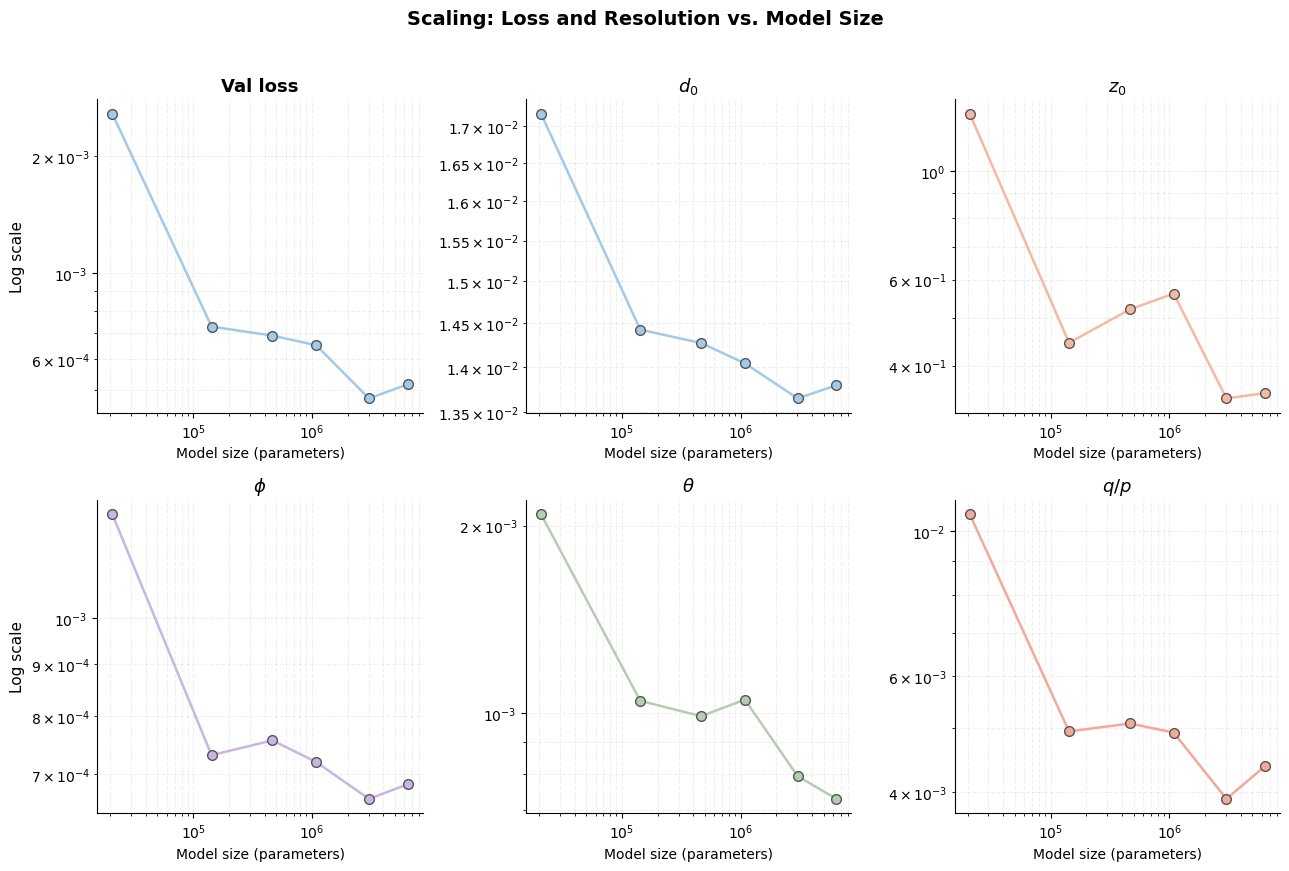

In [45]:
# Best validation loss + all five resolutions vs. model size, log-log, 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
axes = axes.flatten()

axes[0].plot(n_params, val_losses, "o-", color="#a3c9e9", markeredgecolor="#555555", markersize=7, linewidth=1.8)
axes[0].set_title("Val loss", fontsize=13, fontweight="bold")

for ax, p in zip(axes[1:], PARAM_NAMES):
    vals = [scaling_rows[name][p] for name in SCALING_RUNS]
    ax.plot(n_params, vals, "o-", color=param_colors[p], markeredgecolor="#555555", markersize=7, linewidth=1.8)
    ax.set_title(param_labels[p], fontsize=13, fontweight="bold")

for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Model size (parameters)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, which="both", linestyle="--", alpha=0.2)

axes[0].set_ylabel("Log scale", fontsize=11)
axes[3].set_ylabel("Log scale", fontsize=11)
fig.suptitle("Scaling: Loss and Resolution vs. Model Size", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


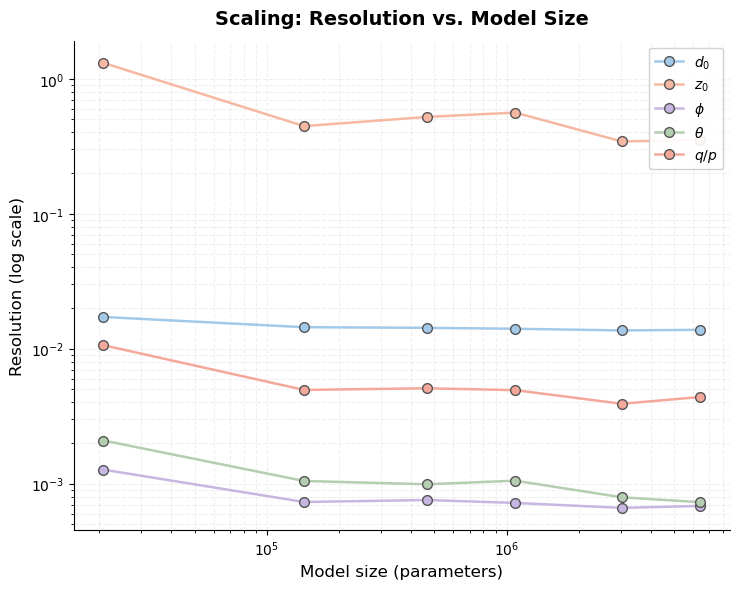

In [42]:
# Per-parameter resolution vs. model size, log-log, all five on one figure
param_colors = {"d0": "#a3c9e9", "z0": "#f6b8a2", "phi": "#c8b6e2", "theta": "#b5cdb0", "qop": "#f4a89a"}
param_labels = {"d0": r"$d_0$", "z0": r"$z_0$", "phi": r"$\phi$", "theta": r"$\theta$", "qop": r"$q/p$"}

fig, ax = plt.subplots(figsize=(7.5, 6))
for p in PARAM_NAMES:
    vals = [scaling_rows[name][p] for name in SCALING_RUNS]
    ax.plot(n_params, vals, "o-", color=param_colors[p], label=param_labels[p],
            markeredgecolor="#555555", markersize=7, linewidth=1.8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Model size (parameters)", fontsize=12)
ax.set_ylabel("Resolution (log scale)", fontsize=12)
ax.set_title("Scaling: Resolution vs. Model Size", fontsize=14, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, which="both", linestyle="--", alpha=0.2)
ax.legend(frameon=True, framealpha=0.9, edgecolor="#cccccc")
fig.tight_layout()
plt.show()


### Updated scaling sweep (exp9c: LR-corrected d256 + new d320/d384)

Replaces the underpowered original d256 (lr=1e-4) with the corrected rerun (lr=2e-4), and adds two new, bigger configurations. 

In [138]:
# Updated run set: d32/d64/d96/d128/d192 unchanged. d256 kept as the
# original corrected rerun (lr=1e-4) : the newer lr=2e-4 rerun tested was
# NOT better (final val_loss 0.00057 vs 0.00054; qop 36% worse), so it is
# not used here. d320/d384 are new, genuinely additional points.
UPDATED_SCALING_RUNS = {
    "d32":  SCALING_RUNS["d32"],
    "d64":  SCALING_RUNS["d64"],
    "d96":  SCALING_RUNS["d96"],
    "d128": SCALING_RUNS["d128"],
    "d192": SCALING_RUNS["d192_corrected"],                              # exp9b_scale_model_d192_L10_lrfix_noposenc
    "d256": SCALING_RUNS["d256_corrected"],                              # exp9b_scale_model_d256_L12_lrfix_noposenc, lr=1e-4 (unchanged from original sweep)
    "d320": BASE_DIR / "exp9c_scale_model_d320_L14_noposenc",
    "d384": BASE_DIR / "exp9c_scale_model_d384_L16_noposenc",
}

missing = {name: str(d) for name, d in UPDATED_SCALING_RUNS.items() if not d.exists()}
if missing:
    print("Not pulled yet:", missing)
else:
    print(f"All {len(UPDATED_SCALING_RUNS)} runs found.")

# ACTS reference resolution, for the flat comparison line on the plot below
# (loaded directly here since exp4's load_acts_comparison() cell runs later in the notebook)
with open(SCALING_RUNS["d192_corrected"] / "acts_comparison.json") as f:
    _acts_ref = json.load(f)
acts_ref_vals = {p: _acts_ref[p]["acts"] for p in PARAM_NAMES}


All 8 runs found.


In [139]:
# Config, depth, peak LR, and resolution for the updated sweep
updated_scaling_rows = {}
for name, run_dir in UPDATED_SCALING_RUNS.items():
    if not run_dir.exists():
        continue
    cfg = load_config(run_dir)
    row = {"num_layers": cfg.get("num_layers"), "peak_lr": cfg.get("lr")}
    row.update(load_resolutions(run_dir))
    updated_scaling_rows[name] = row

updated_scaling_df = pd.DataFrame(updated_scaling_rows).T
updated_scaling_df.index.name = "config"
print("Updated model-scaling sweep, including exp9c reruns.")
updated_scaling_df.style.format({"num_layers": "{:.0f}", "peak_lr": "{:.0e}", **{p: "{:.5f}" for p in PARAM_NAMES}})


Updated model-scaling sweep, including exp9c reruns.


,num_layers,peak_lr,d0,z0,phi,theta,qop
config,,,,,,,
d32,2,1e-03,0.01717,1.30993,0.00127,0.00209,0.01061
d64,4,1e-03,0.01443,0.44557,0.00073,0.00105,0.00495
d96,6,1e-03,0.01427,0.52124,0.00076,0.00099,0.00509
d128,8,1e-03,0.01404,0.56153,0.00072,0.00105,0.00493
d192,10,2e-04,0.01365,0.34295,0.00066,0.00079,0.00390
d256,12,1e-04,0.01380,0.35161,0.00068,0.00073,0.00438
d320,14,1e-04,0.01405,0.43964,0.00081,0.00081,0.01231
d384,16,1e-04,0.01387,0.31259,0.00067,0.00069,0.00489


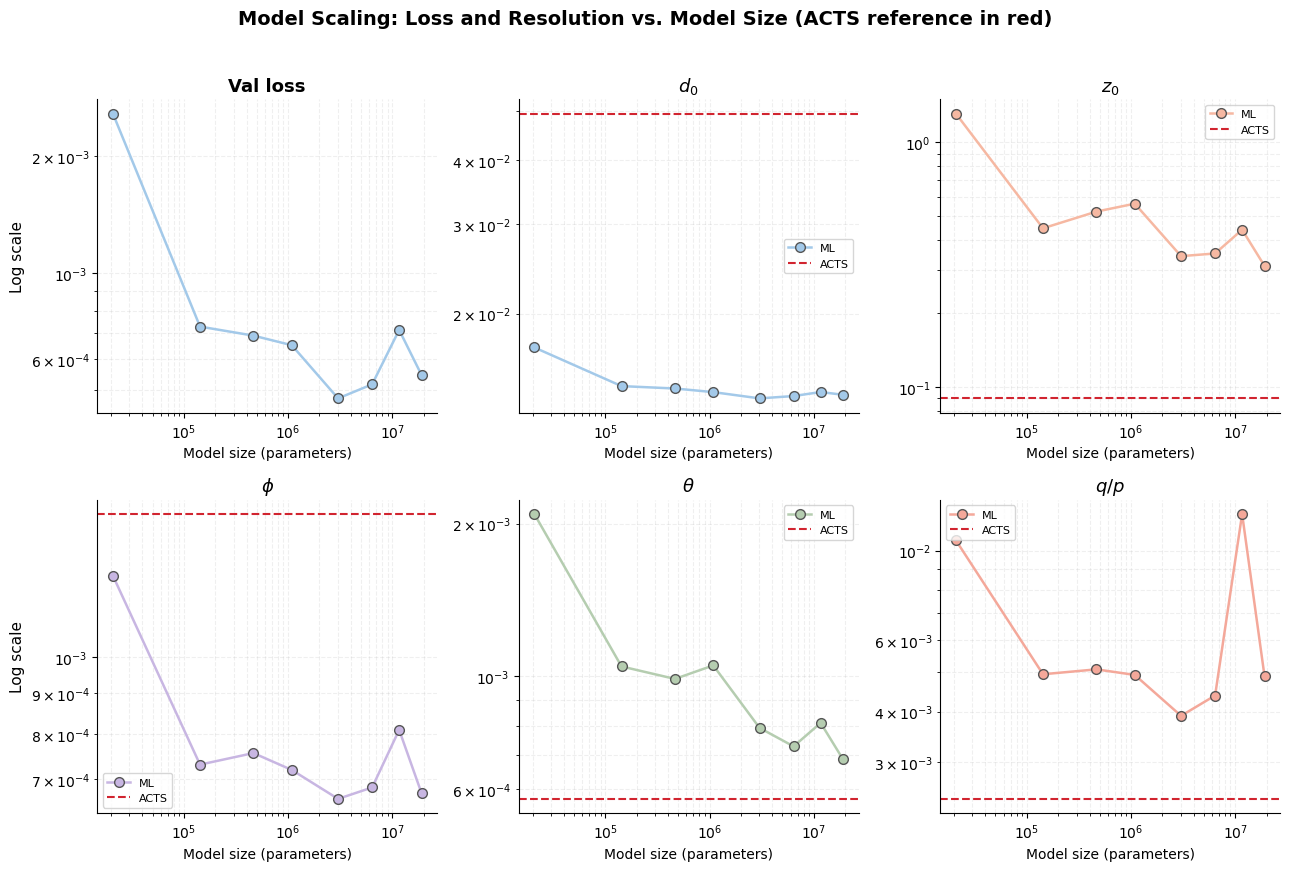

In [141]:
# Best validation loss + all five resolutions vs. model size, log-log, updated sweep
# ACTS reference (flat dashed line) shown on the five resolution panels
updated_n_params = [load_config(d).get("n_params") for d in UPDATED_SCALING_RUNS.values() if d.exists()]
updated_val_losses = [json.load(open(d / "run_summary.json")).get("best_val_loss")
                       for d in UPDATED_SCALING_RUNS.values() if d.exists()]

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
axes = axes.flatten()

axes[0].plot(updated_n_params, updated_val_losses, "o-", color="#a3c9e9", markeredgecolor="#555555", markersize=7, linewidth=1.8)
axes[0].set_title("Val loss", fontsize=13, fontweight="bold")

for ax, p in zip(axes[1:], PARAM_NAMES):
    vals = [updated_scaling_rows[name][p] for name in updated_scaling_rows]
    ax.plot(updated_n_params, vals, "o-", color=param_colors[p], markeredgecolor="#555555", markersize=7, linewidth=1.8, label="ML")
    ax.axhline(acts_ref_vals[p], color="#d1242f", linestyle="--", linewidth=1.5, label="ACTS")
    ax.set_title(param_labels[p], fontsize=13, fontweight="bold")
    ax.legend(fontsize=8)

for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Model size (parameters)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, which="both", linestyle="--", alpha=0.2)

axes[0].set_ylabel("Log scale", fontsize=11)
axes[3].set_ylabel("Log scale", fontsize=11)
fig.suptitle("Model Scaling: Loss and Resolution vs. Model Size (ACTS reference in red)", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


### Scaling plot with bootstrap 68% CI

Separate from the plots above -- same updated run set, but with a bootstrap confidence interval per point instead of a bare marker. Note this CI reflects sampling noise on the resolution estimate from a fixed test set, not seed-to-seed training variance (see to-do list).

In [142]:
# Self-contained here since exp4's helpers are defined later in the notebook
def robust_resolution(residuals):
    q75, q25 = np.percentile(residuals, [75, 25])
    return (q75 - q25) / 1.349

def bootstrap_ci(residuals, n_boot=500, ci=68, seed=0):
    rng = np.random.default_rng(seed)
    residuals = np.asarray(residuals)
    n = len(residuals)
    boot_res = [robust_resolution(rng.choice(residuals, size=n, replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(boot_res, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return lo, hi

def wrap(x):
    return np.remainder(x + np.pi, 2 * np.pi) - np.pi

def scaling_point_and_err(run_dir, param):
    df = pd.read_parquet(run_dir / "comparison_light.parquet")
    r = df[f"ml_{param}"] - df[param]
    r = wrap(r) if param in ("phi", "theta") else r
    val = robust_resolution(r)
    lo, hi = bootstrap_ci(r)
    return val, val - lo, hi - val


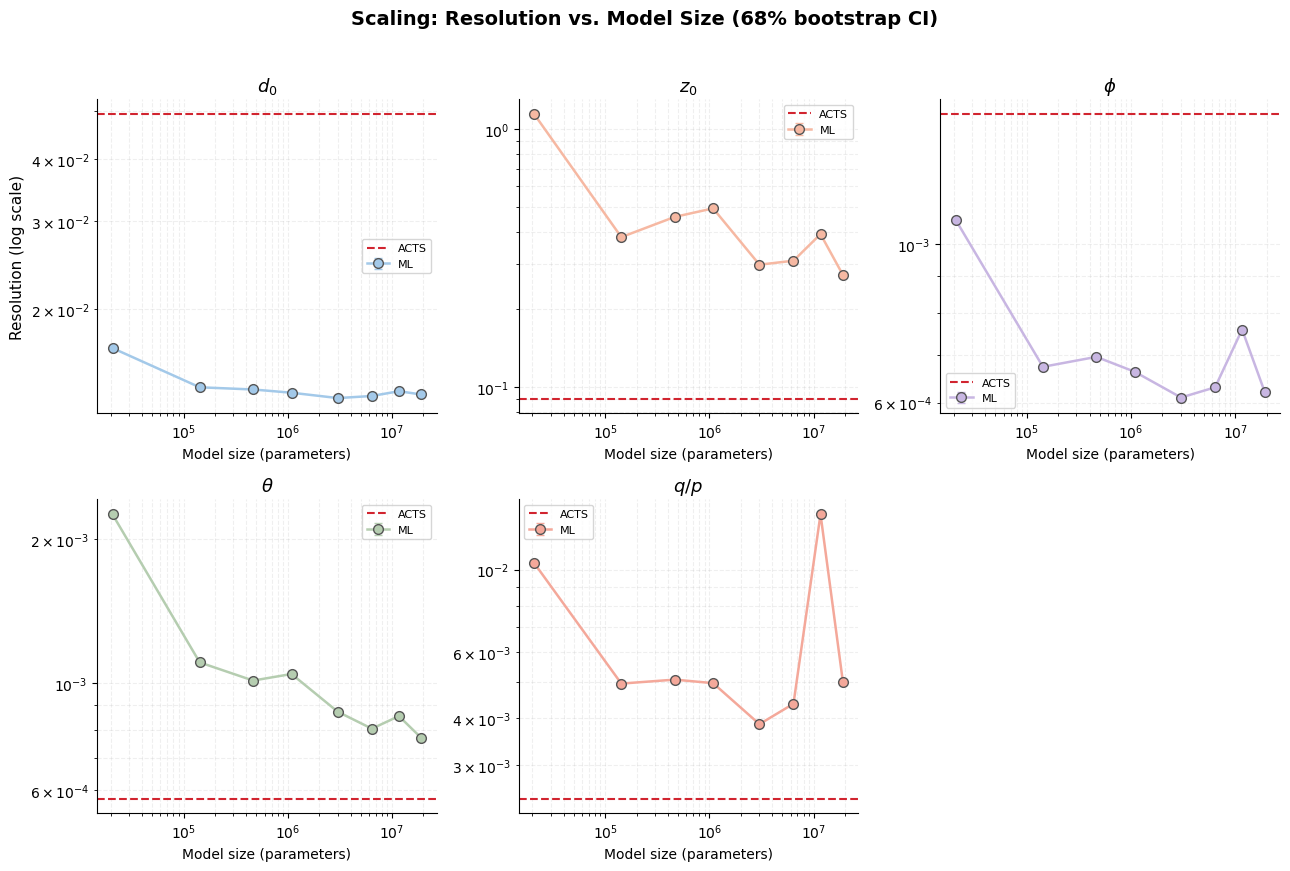

In [143]:
# All five resolutions vs. model size, log-log, with bootstrap 68% CI
fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
axes = axes.flatten()
axes[-1].set_visible(False)

for ax, p in zip(axes, PARAM_NAMES):
    vals, los, his = [], [], []
    for name in UPDATED_SCALING_RUNS:
        v, lo, hi = scaling_point_and_err(UPDATED_SCALING_RUNS[name], p)
        vals.append(v); los.append(lo); his.append(hi)
    ax.errorbar(updated_n_params, vals, yerr=[los, his], fmt="o-", color=param_colors[p],
                ecolor=param_colors[p], markeredgecolor="#555555", markersize=7,
                linewidth=1.8, capsize=3, label="ML")
    ax.axhline(acts_ref_vals[p], color="#d1242f", linestyle="--", linewidth=1.5, label="ACTS")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Model size (parameters)", fontsize=10)
    ax.set_title(param_labels[p], fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, which="both", linestyle="--", alpha=0.2)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Resolution (log scale)", fontsize=11)
fig.suptitle("Scaling: Resolution vs. Model Size (68% bootstrap CI)", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## Comparison to ACTS

Best config from scaling: `d192_corrected`.

In [128]:
BEST = SCALING_RUNS["d192_corrected"]

def load_acts_comparison(run_dir):
    with open(run_dir / "acts_comparison.json") as f:
        return json.load(f)

acts_comp = load_acts_comparison(BEST)


In [129]:
# ML vs. ACTS resolution, best config
acts_table = {p: {"ML": acts_comp[p]["ml"], "ACTS": acts_comp[p]["acts"]} for p in PARAM_NAMES}
acts_df = pd.DataFrame(acts_table).T
print(f"ML vs. ACTS resolution, d192 (corrected). Match rate: {acts_comp['match_rate']:.3f}")
acts_df.style.format("{:.5f}")


ML vs. ACTS resolution, d192 (corrected). Match rate: 0.877


,ML,ACTS
d0,0.01328,0.04932
z0,0.29774,0.09005
phi,0.00061,0.00152
theta,0.00087,0.00057
qop,0.00386,0.00243


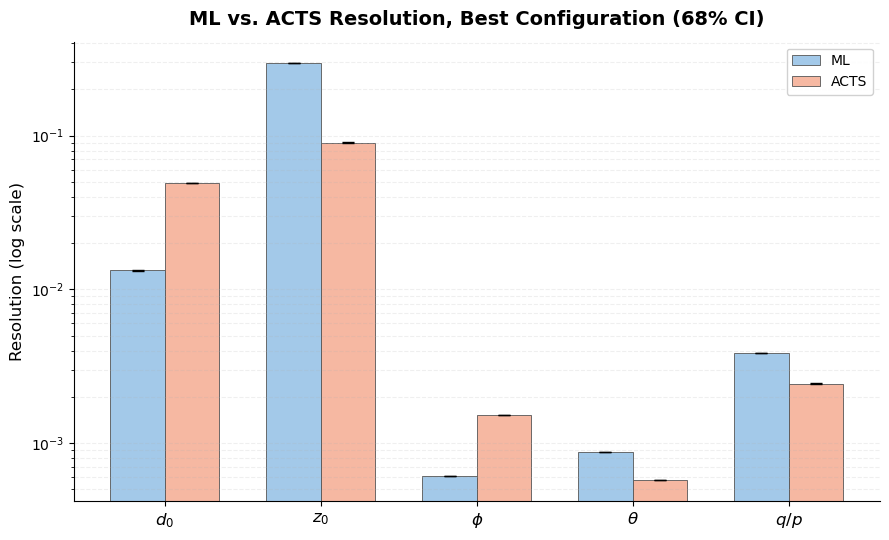

In [130]:
# ML vs. ACTS, all five parameters, one figure, log scale, with 68% CI
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(PARAM_NAMES))
width = 0.35
colors = {"ML": "#a3c9e9", "ACTS": "#f6b8a2"}
keys = {"ML": "ml", "ACTS": "acts"}

for i, label in enumerate(["ML", "ACTS"]):
    key = keys[label]
    vals = [acts_comp[p][key] for p in PARAM_NAMES]
    los = [acts_comp[p][f"{key}_ci68"][0] for p in PARAM_NAMES]
    his = [acts_comp[p][f"{key}_ci68"][1] for p in PARAM_NAMES]
    errs = [[v - lo for v, lo in zip(vals, los)], [hi - v for v, hi in zip(vals, his)]]
    ax.bar(x + (i - 0.5) * width, vals, width, yerr=errs, capsize=4, label=label,
           color=colors[label], edgecolor="#555555", linewidth=0.6)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([r"$d_0$", r"$z_0$", r"$\phi$", r"$\theta$", r"$q/p$"], fontsize=12)
ax.set_ylabel("Resolution (log scale)", fontsize=12)
ax.set_title("ML vs. ACTS Resolution, Best Configuration (68% CI)", fontsize=14, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="y", which="both", linestyle="--", alpha=0.2)
ax.legend(frameon=True, framealpha=0.9, edgecolor="#cccccc")
fig.tight_layout()
plt.show()


In [111]:
# Per-track ML + ACTS predictions for the binned plots below
tdf = pd.read_parquet(BEST / "comparison_light.parquet")
tdf["eta"] = -np.log(np.tan(tdf["theta"] / 2))

def robust_resolution(residuals):
    """IQR/1.349, the resolution metric used throughout Study 1."""
    q75, q25 = np.percentile(residuals, [75, 25])
    return (q75 - q25) / 1.349

def wrap(x):
    """Wrap angle residuals to [-pi, pi]."""
    return np.remainder(x + np.pi, 2 * np.pi) - np.pi

def residual(df_, param, source):
    """source is 'ml' or 'acts'."""
    r = df_[f"{source}_{param}"] - df_[param]
    return wrap(r) if param in ("phi", "theta") else r

# Parameter shown in the binned plots below -- change to inspect a different one
BIN_PARAM = "qop"
BIN_PARAM_LABEL = {"d0": r"$d_0$", "z0": r"$z_0$", "phi": r"$\phi$", "theta": r"$\theta$", "qop": r"$q/p$"}[BIN_PARAM]

# d0 and phi track ACTS closely; z0, theta, qop lag further behind -- grouped for easier reading
ORDERED_PARAMS = ["d0", "phi", "z0", "theta", "qop"]

def bootstrap_ci(residuals, n_boot=1000, ci=68, seed=0):
    """Bootstrap CI on robust_resolution: resample residuals with replacement, n_boot times."""
    rng = np.random.default_rng(seed)
    residuals = np.asarray(residuals)
    n = len(residuals)
    boot_res = [robust_resolution(rng.choice(residuals, size=n, replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(boot_res, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return lo, hi

def point_and_err(residuals):
    """Point estimate + asymmetric error bar sizes for plt.errorbar/plt.bar yerr."""
    val = robust_resolution(residuals)
    lo, hi = bootstrap_ci(residuals)
    return val, [val - lo], [hi - val]


<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
/var/folders/d6/dd2n1fb92w94g58fxsjhn1yh0000gn/T/ipykernel_6354/1295114158.py:35: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle("Resolution vs. $\eta$, ML vs. ACTS (68% bootstrap CI)", fontsize=14, fontweight="bold", y=1.02)


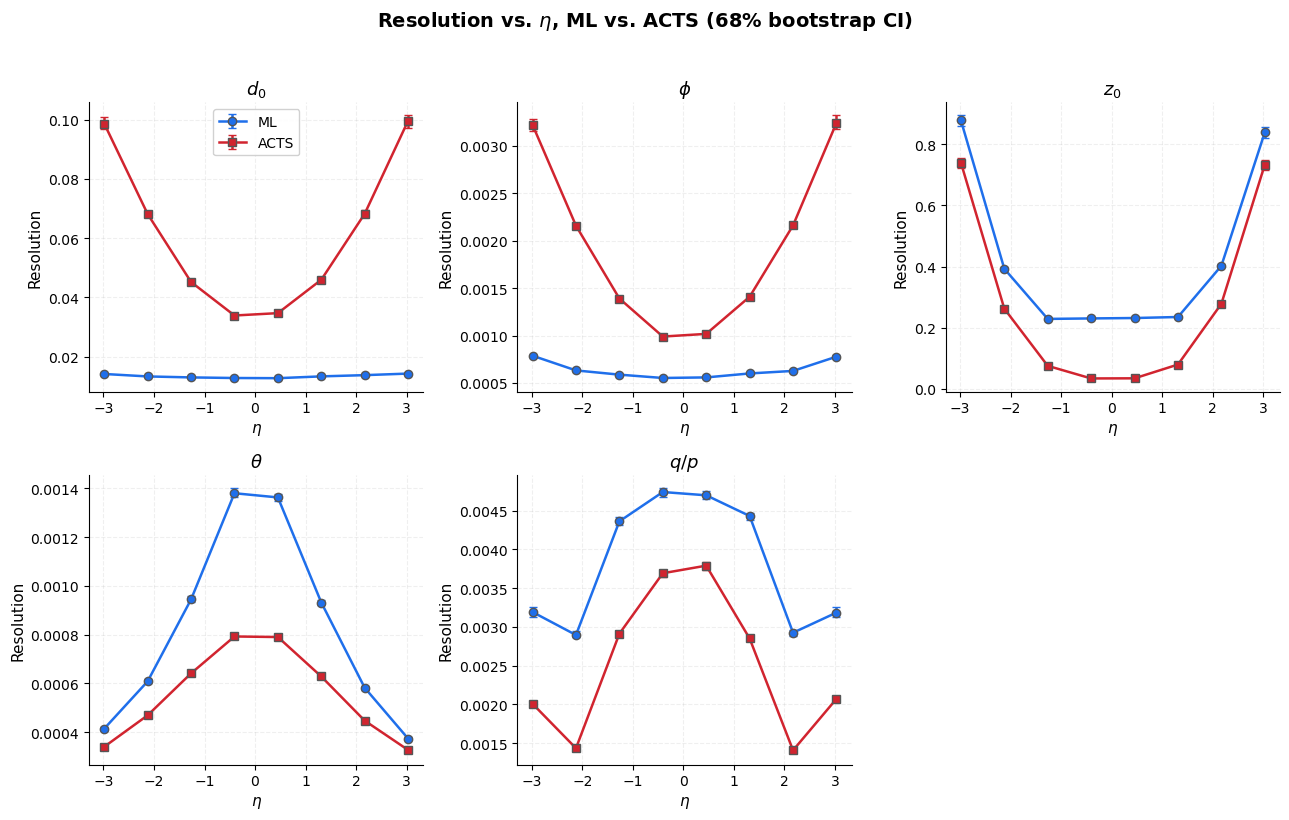

In [112]:
# Resolution vs. eta, ML vs. ACTS, all five parameters, with bootstrap 68% CI
param_labels_full = {"d0": r"$d_0$", "z0": r"$z_0$", "phi": r"$\phi$", "theta": r"$\theta$", "qop": r"$q/p$"}

eta_bins = np.linspace(tdf["eta"].min(), tdf["eta"].max(), 9)
tdf["eta_bin"] = pd.cut(tdf["eta"], bins=eta_bins)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, p in zip(axes, ORDERED_PARAMS):
    xs, ml_vals, ml_errs, acts_vals, acts_errs = [], [], [], [], []
    for b, g in tdf.groupby("eta_bin", observed=True):
        if len(g) < 5:
            continue
        xs.append(b.mid)
        v, lo, hi = point_and_err(residual(g, p, "ml"))
        ml_vals.append(v); ml_errs.append([lo[0], hi[0]])
        v, lo, hi = point_and_err(residual(g, p, "acts"))
        acts_vals.append(v); acts_errs.append([lo[0], hi[0]])

    ml_errs = np.array(ml_errs).T
    acts_errs = np.array(acts_errs).T
    ax.errorbar(xs, ml_vals, yerr=ml_errs, fmt="o-", color="#1f6feb", ecolor="#1f6feb",
                markeredgecolor="#555555", markersize=6, linewidth=1.8, capsize=3, label="ML")
    ax.errorbar(xs, acts_vals, yerr=acts_errs, fmt="s-", color="#d1242f", ecolor="#d1242f",
                markeredgecolor="#555555", markersize=6, linewidth=1.8, capsize=3, label="ACTS")
    ax.set_xlabel(r"$\eta$", fontsize=11)
    ax.set_ylabel("Resolution", fontsize=11)
    ax.set_title(param_labels_full[p], fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.2)

axes[0].legend(frameon=True, framealpha=0.9, edgecolor="#cccccc")
axes[-1].set_visible(False)
fig.suptitle("Resolution vs. $\eta$, ML vs. ACTS (68% bootstrap CI)", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


In [ ]:
# Mean true parameter value vs. eta, all five parameters -- sanity check for
# any natural eta-dependence in the truth itself (separate from ML/ACTS
# resolution, which is a spread statistic, not a raw value)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, p in zip(axes, ORDERED_PARAMS):
    xs, means = [], []
    for b, g in tdf.groupby("eta_bin", observed=True):
        if len(g) < 5:
            continue
        xs.append(b.mid)
        means.append(g[p].mean())
    ax.plot(xs, means, "o-", color="#2ca02c", markeredgecolor="#555555", markersize=6, linewidth=1.8, label="Truth (mean)")
    ax.set_xlabel(r"$\eta$", fontsize=11)
    ax.set_ylabel("True value (mean)", fontsize=11)
    ax.set_title(param_labels_full[p], fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.2)

axes[-1].set_visible(False)
fig.suptitle("Mean True Parameter Value vs. $\eta$", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


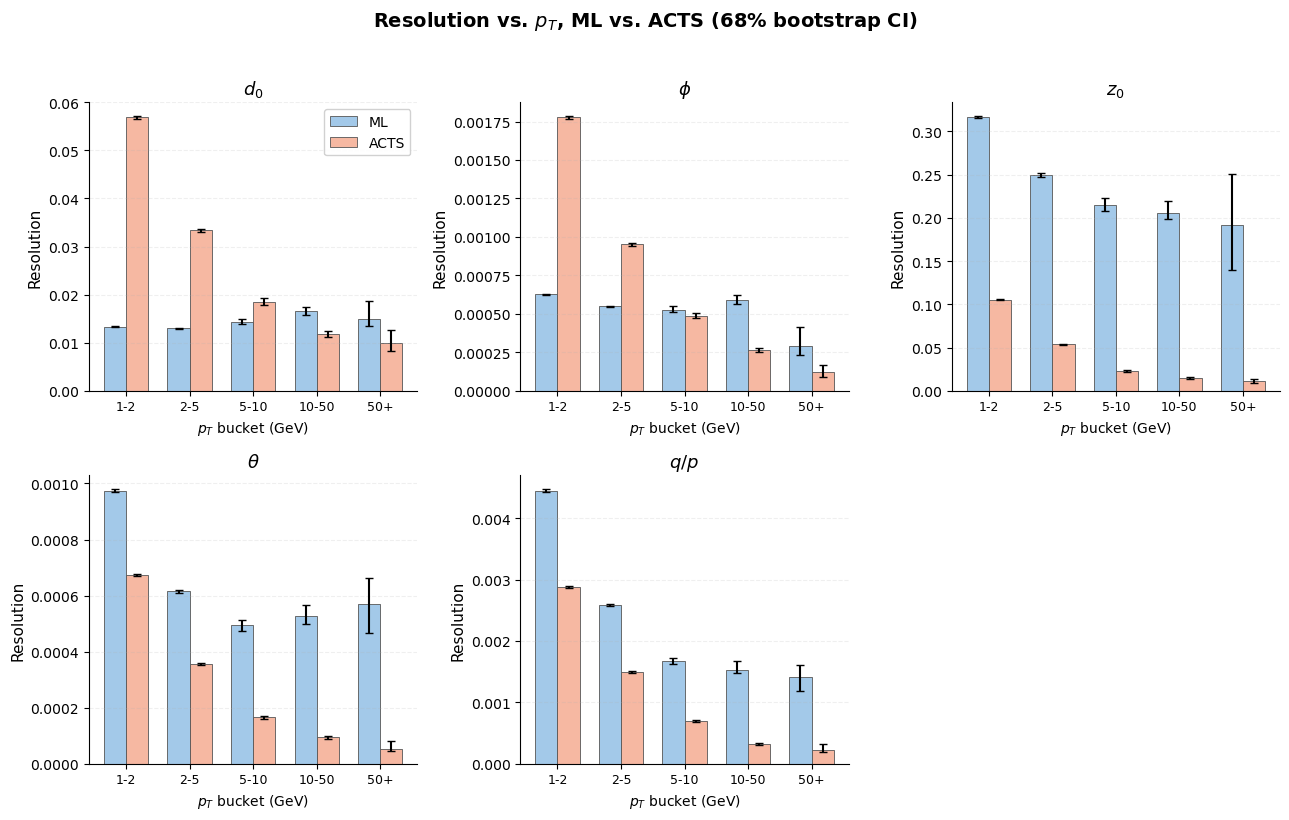

In [113]:
# Resolution vs. pT, ML vs. ACTS, all five parameters, with bootstrap 68% CI
pt_bins = [0, 1.0, 2.0, 5.0, 10.0, 50.0, np.inf]
pt_labels = ["<1", "1-2", "2-5", "5-10", "10-50", "50+"]
tdf["pt_bin"] = pd.cut(tdf["pt"], bins=pt_bins, labels=pt_labels)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, p in zip(axes, ORDERED_PARAMS):
    bins, ml_vals, ml_errs, acts_vals, acts_errs = [], [], [], [], []
    for b, g in tdf.groupby("pt_bin", observed=True):
        if len(g) < 5:
            continue
        bins.append(str(b))
        v, lo, hi = point_and_err(residual(g, p, "ml"))
        ml_vals.append(v); ml_errs.append([lo[0], hi[0]])
        v, lo, hi = point_and_err(residual(g, p, "acts"))
        acts_vals.append(v); acts_errs.append([lo[0], hi[0]])

    x = np.arange(len(bins))
    width = 0.35
    ax.bar(x - width/2, ml_vals, width, yerr=np.array(ml_errs).T, capsize=3,
           label="ML", color="#a3c9e9", edgecolor="#555555", linewidth=0.6)
    ax.bar(x + width/2, acts_vals, width, yerr=np.array(acts_errs).T, capsize=3,
           label="ACTS", color="#f6b8a2", edgecolor="#555555", linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(bins, fontsize=9)
    ax.set_xlabel("$p_T$ bucket (GeV)", fontsize=10)
    ax.set_ylabel("Resolution", fontsize=11)
    ax.set_title(param_labels_full[p], fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, axis="y", linestyle="--", alpha=0.2)

axes[0].legend(frameon=True, framealpha=0.9, edgecolor="#cccccc")
axes[-1].set_visible(False)
fig.suptitle("Resolution vs. $p_T$, ML vs. ACTS (68% bootstrap CI)", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


### Checking for shrinkage in the low-$p_T$ ML advantage

In [145]:
# Does ML's low-pT advantage on d0/phi come from genuinely better per-track
# estimation, or from shrinkage (predictions pulled toward the population
# mean, trading bias for variance)? Test: OLS slope of predicted vs. true
# value in a low-pT and a high-pT bucket. Slope = 1 -> unbiased.
# Slope < 1 -> predictions compressed toward the mean (shrinkage).

def calibration_slope(true_vals, pred_vals):
    slope, _ = np.polyfit(true_vals, pred_vals, 1)
    return slope

LOW_PT = tdf["pt"] < 2.0
HIGH_PT = tdf["pt"] > 10.0

print(f"{'param':<6}{'bucket':<10}{'ML slope':<12}{'ACTS slope':<12}")
for p in ["d0", "phi"]:
    for label, mask in [("low pT", LOW_PT), ("high pT", HIGH_PT)]:
        g = tdf[mask]
        ml_slope = calibration_slope(g[p], g[f"ml_{p}"])
        acts_slope = calibration_slope(g[p], g[f"acts_{p}"])
        print(f"{p:<6}{label:<10}{ml_slope:<12.3f}{acts_slope:<12.3f}")

param bucket    ML slope    ACTS slope  
d0    low pT    0.918       0.720       
d0    high pT   0.982       1.034       
phi   low pT    0.999       0.994       
phi   high pT   1.000       0.993       


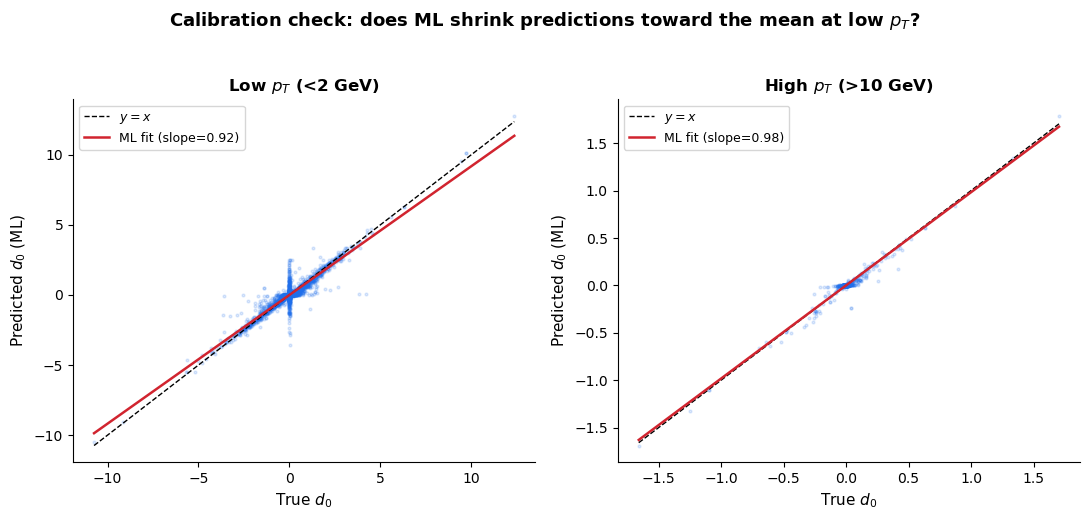

In [146]:
# Visualise the same check for d0: predicted vs. true, low- vs. high-pT,
# with the y=x line (unbiased) and the fitted slope (actual behaviour).
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (label, mask) in zip(axes, [("Low $p_T$ (<2 GeV)", LOW_PT), ("High $p_T$ (>10 GeV)", HIGH_PT)]):
    g = tdf[mask]
    ax.scatter(g["d0"], g["ml_d0"], s=4, alpha=0.15, color="#1f6feb")
    lims = [g["d0"].min(), g["d0"].max()]
    ax.plot(lims, lims, "k--", linewidth=1, label="$y=x$")
    slope = calibration_slope(g["d0"], g["ml_d0"])
    fit_x = np.array(lims)
    ax.plot(fit_x, slope * fit_x, color="#d1242f", linewidth=1.8, label=f"ML fit (slope={slope:.2f})")
    ax.set_xlabel("True $d_0$", fontsize=11)
    ax.set_ylabel("Predicted $d_0$ (ML)", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Calibration check: does ML shrink predictions toward the mean at low $p_T$?", fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

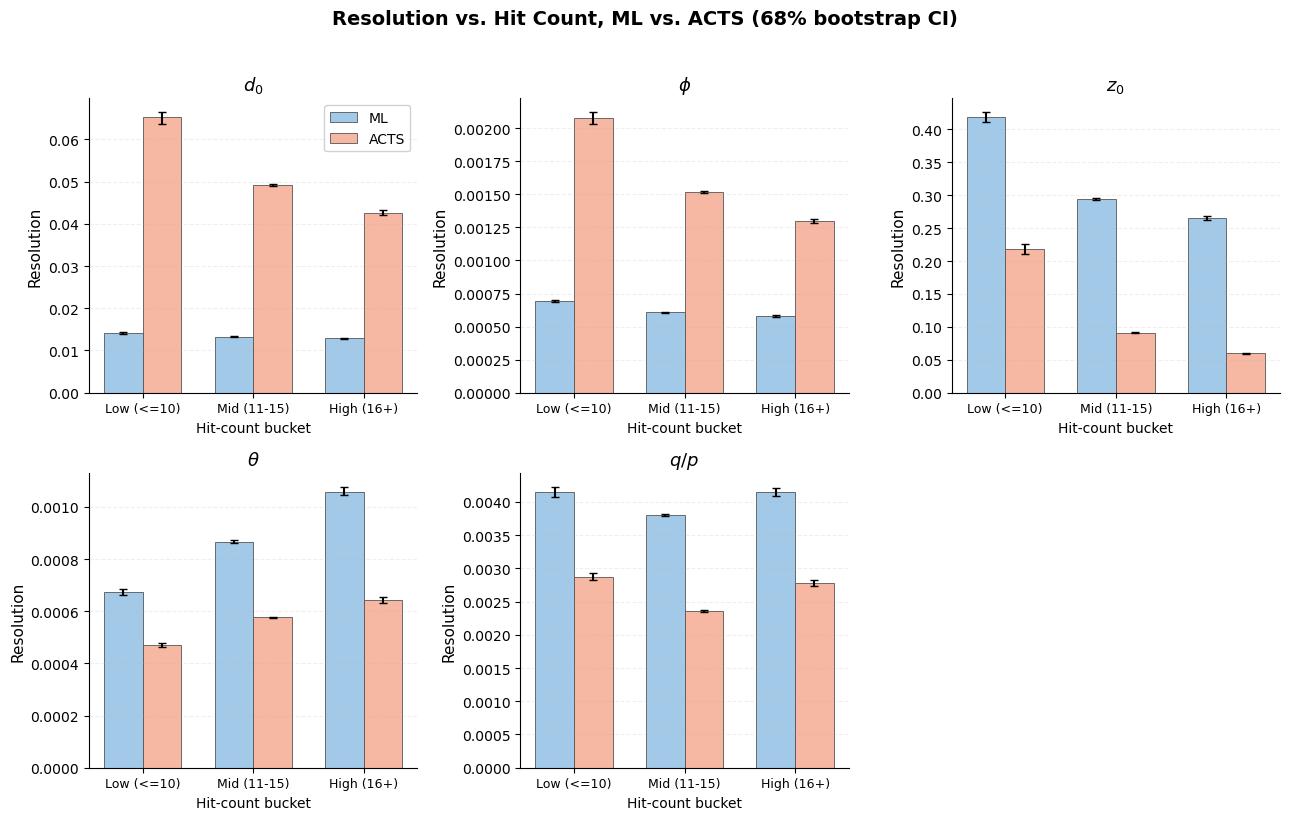

In [114]:
# Resolution vs. hit count, ML vs. ACTS, all five parameters, with bootstrap 68% CI
hit_edges = [tdf["calculated_hits"].min() - 0.5, 10.5, 15.5, tdf["calculated_hits"].max() + 0.5]
hit_labels = ["Low (<=10)", "Mid (11-15)", "High (16+)"]
tdf["hit_bin"] = pd.cut(tdf["calculated_hits"], bins=hit_edges, labels=hit_labels)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, p in zip(axes, ORDERED_PARAMS):
    bins, ml_vals, ml_errs, acts_vals, acts_errs = [], [], [], [], []
    for b, g in tdf.groupby("hit_bin", observed=True):
        if len(g) < 5:
            continue
        bins.append(str(b))
        v, lo, hi = point_and_err(residual(g, p, "ml"))
        ml_vals.append(v); ml_errs.append([lo[0], hi[0]])
        v, lo, hi = point_and_err(residual(g, p, "acts"))
        acts_vals.append(v); acts_errs.append([lo[0], hi[0]])

    x = np.arange(len(bins))
    width = 0.35
    ax.bar(x - width/2, ml_vals, width, yerr=np.array(ml_errs).T, capsize=3,
           label="ML", color="#a3c9e9", edgecolor="#555555", linewidth=0.6)
    ax.bar(x + width/2, acts_vals, width, yerr=np.array(acts_errs).T, capsize=3,
           label="ACTS", color="#f6b8a2", edgecolor="#555555", linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(bins, fontsize=9)
    ax.set_xlabel("Hit-count bucket", fontsize=10)
    ax.set_ylabel("Resolution", fontsize=11)
    ax.set_title(param_labels_full[p], fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, axis="y", linestyle="--", alpha=0.2)

axes[0].legend(frameon=True, framealpha=0.9, edgecolor="#cccccc")
axes[-1].set_visible(False)
fig.suptitle("Resolution vs. Hit Count, ML vs. ACTS (68% bootstrap CI)", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


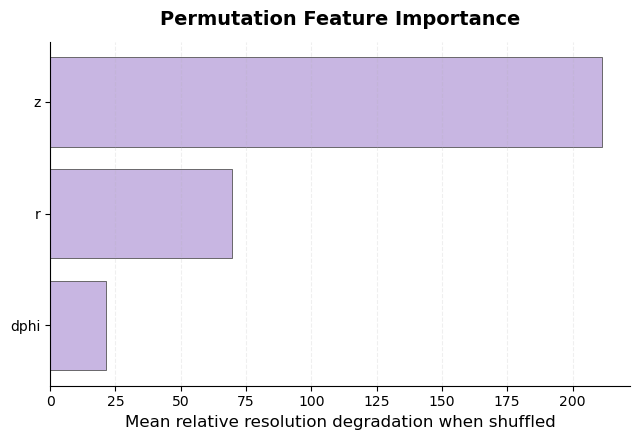

In [115]:
# Permutation feature importance, sorted descending
with open(BEST / "feature_importance.json") as f:
    fi = json.load(f)

importances = dict(sorted(fi["importances"].items(), key=lambda kv: kv[1], reverse=True))
features = list(importances.keys())
values = list(importances.values())

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.barh(features, values, color="#c8b6e2", edgecolor="#555555", linewidth=0.6)
ax.invert_yaxis()
ax.set_xlabel("Mean relative resolution degradation when shuffled", fontsize=12)
ax.set_title("Permutation Feature Importance", fontsize=14, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="x", linestyle="--", alpha=0.2)
fig.tight_layout()
plt.show()


### Prediction vs. truth heatmap

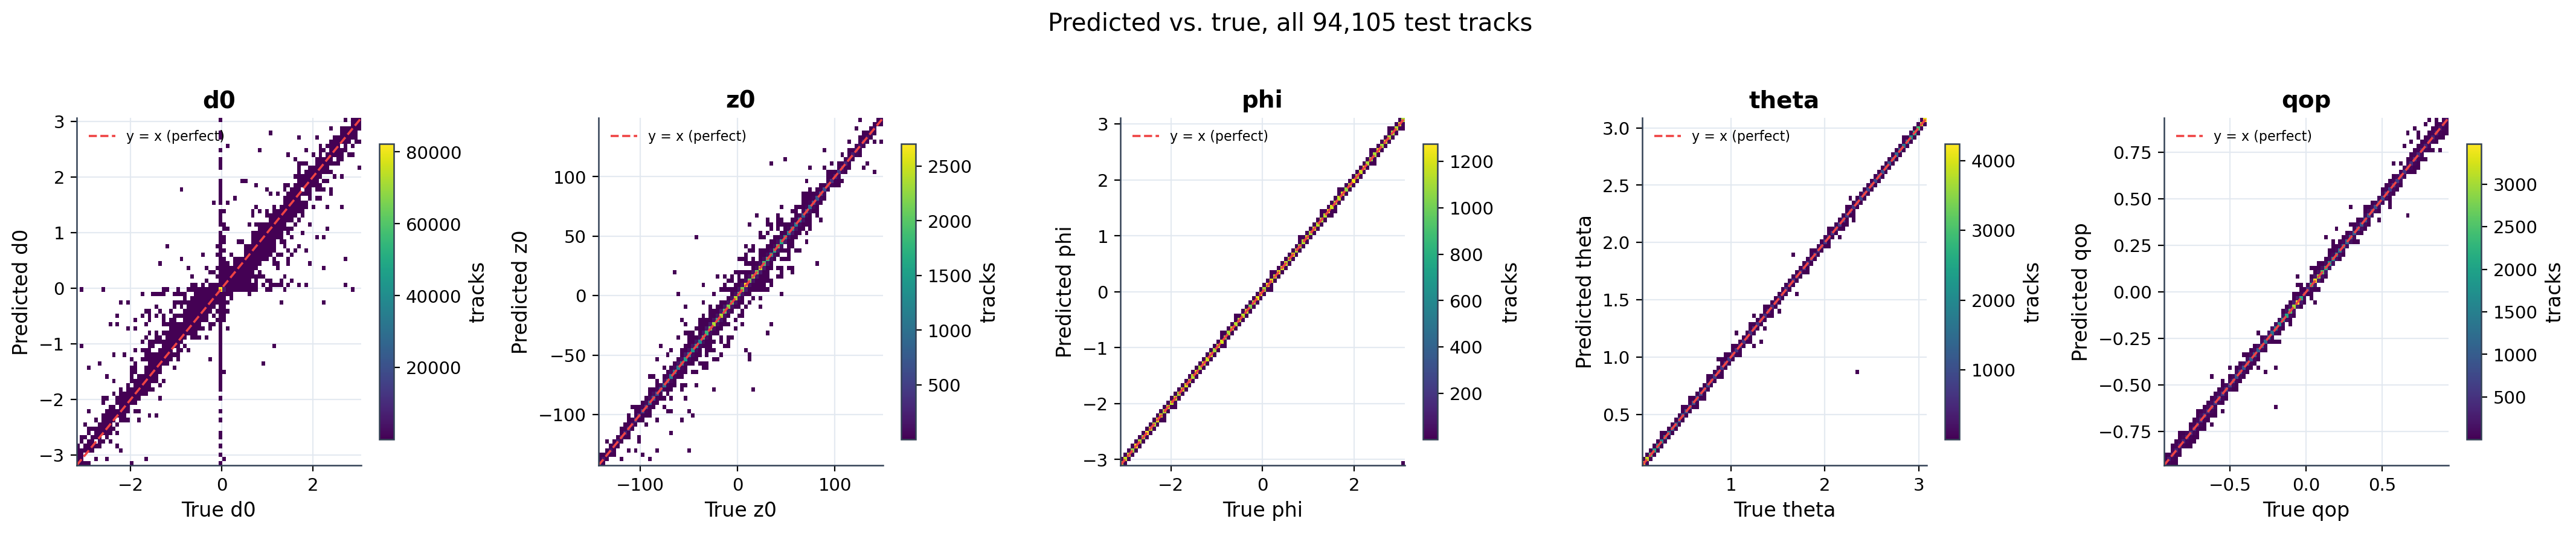

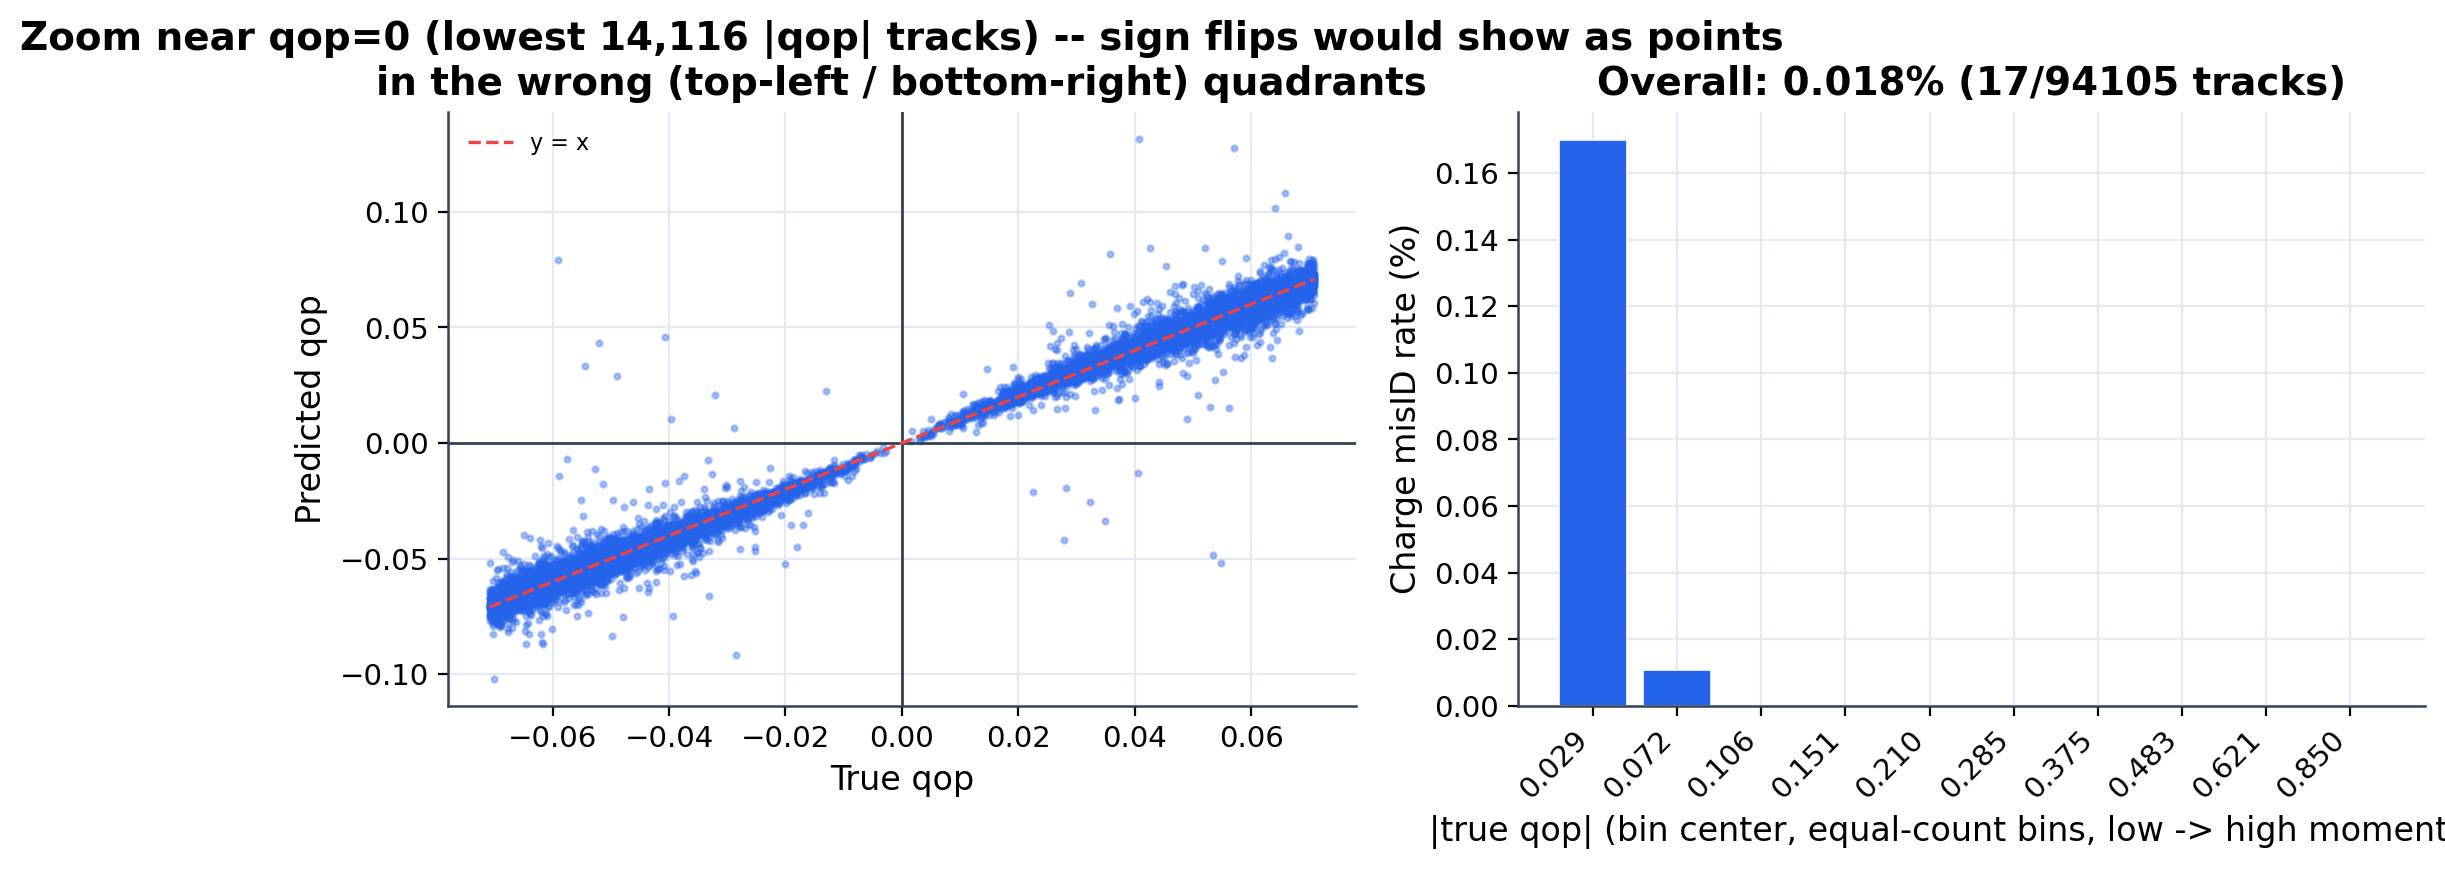

In [133]:
# Prediction vs. truth density heatmap, and qop sign-check, best config
for plot_name in ["plot_pred_vs_true.png", "plot_qop_sign_check.png"]:
    plot_path = BEST / plot_name
    if plot_path.exists():
        display(Image(filename=str(plot_path), width=1000))
    else:
        print(f"  (missing: {plot_path})")


### $d_0$ heatmap, zoomed to $|d_0|\leq4$

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/var/folders/d6/dd2n1fb92w94g58fxsjhn1yh0000gn/T/ipykernel_6354/4082588866.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title("Predicted vs. true $d_0$, zoomed to $|d_0|\leq4$", fontsize=12, fontweight="bold")


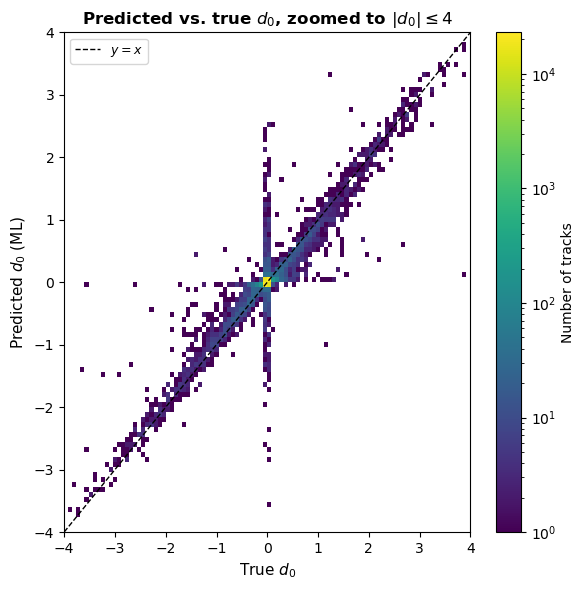

In [147]:
# Couthures's own d0 heatmap (Fig. 6.14) shows the near-zero bias most
# clearly beyond |d0|=2, past the range of the full-scale heatmap above.
# Rebuild the same predicted-vs-truth density plot for d0 only, zoomed to
# |d0| <= 4, to check the same region.
from matplotlib.colors import LogNorm

mask = (tdf["d0"].abs() <= 4) & (tdf["ml_d0"].abs() <= 4)
g = tdf[mask]

fig, ax = plt.subplots(figsize=(6, 6))
h = ax.hist2d(g["d0"], g["ml_d0"], bins=100, range=[[-4, 4], [-4, 4]], cmap="viridis", norm=LogNorm())
ax.plot([-4, 4], [-4, 4], "k--", linewidth=1, label="$y=x$")
ax.set_xlabel("True $d_0$", fontsize=11)
ax.set_ylabel("Predicted $d_0$ (ML)", fontsize=11)
ax.set_title("Predicted vs. true $d_0$, zoomed to $|d_0|\leq4$", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
fig.colorbar(h[3], ax=ax, label="Number of tracks")
fig.tight_layout()
plt.show()

### Attention maps

Needs `visualize_attention.py --run-dir runs/exp9b_scale_model_d192_L10_lrfix_noposenc --n-tracks 4` run on the cluster first, then pulled down into this run's folder.

**attention_track25388.png**

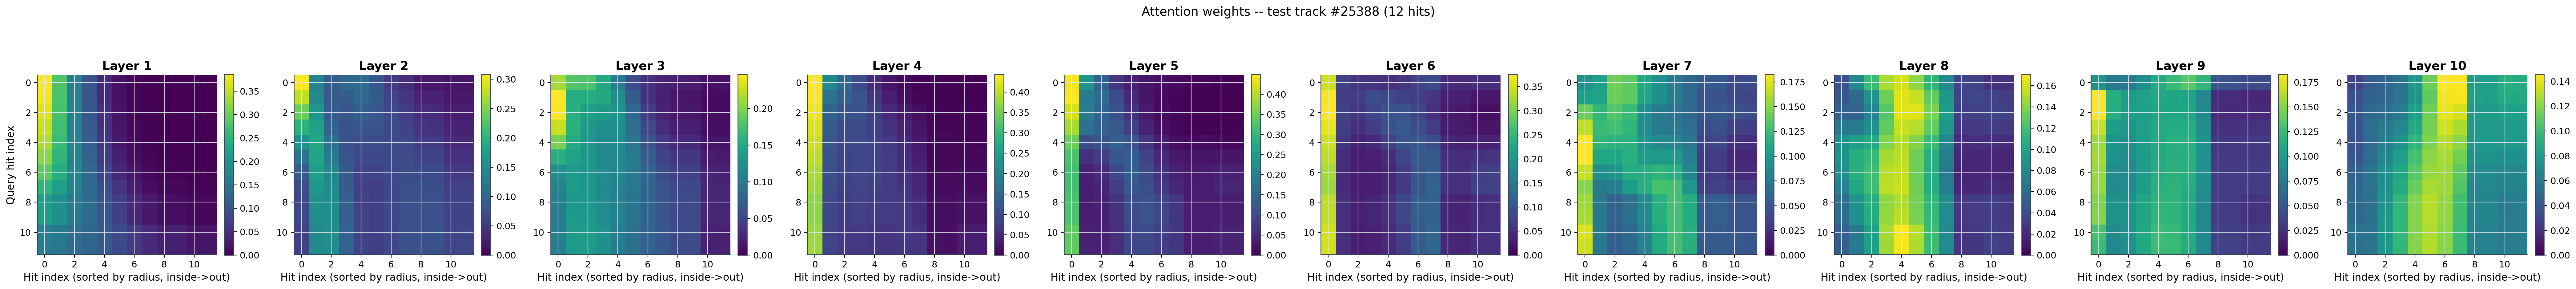

**attention_track48099.png**

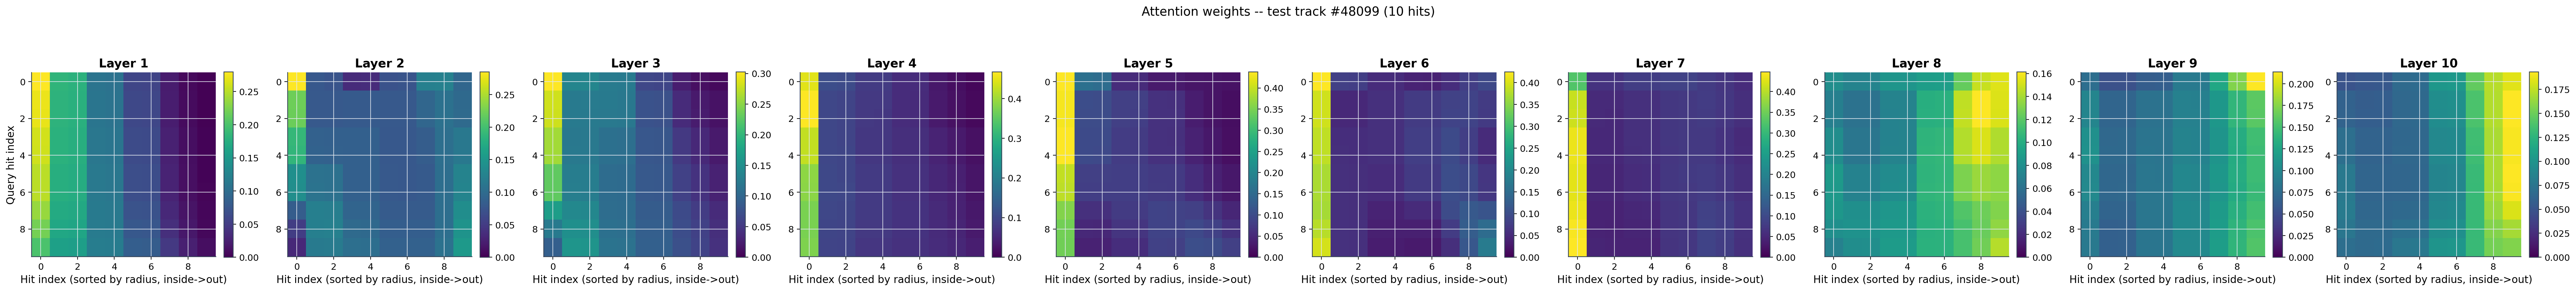

**attention_track59940.png**

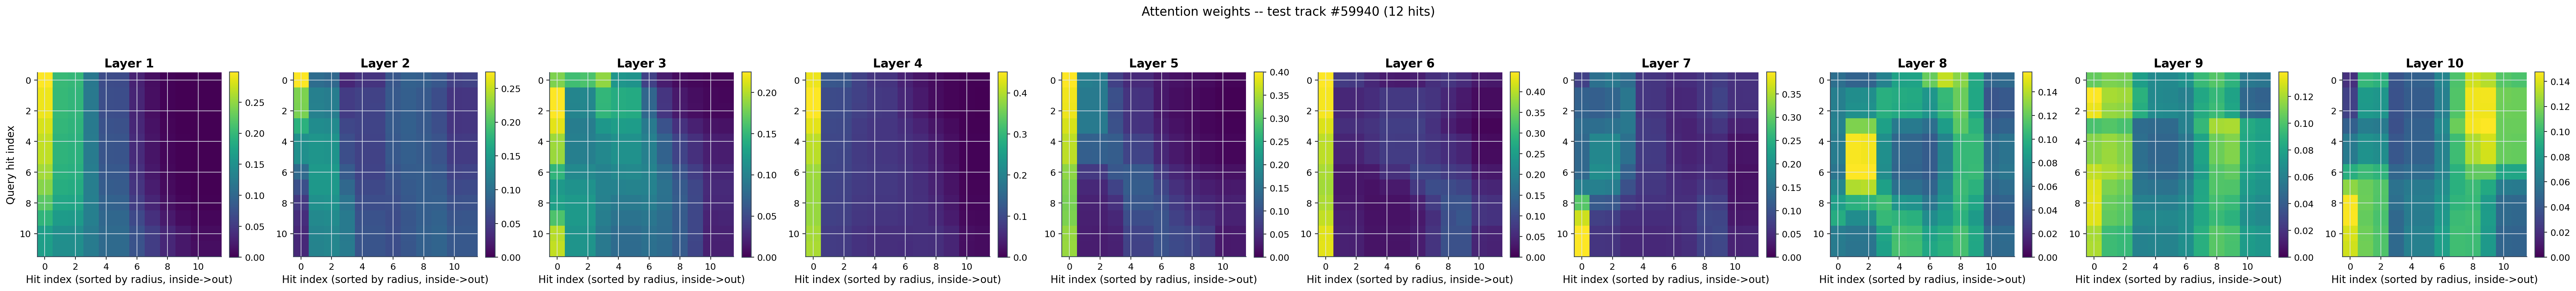

**attention_track80045.png**

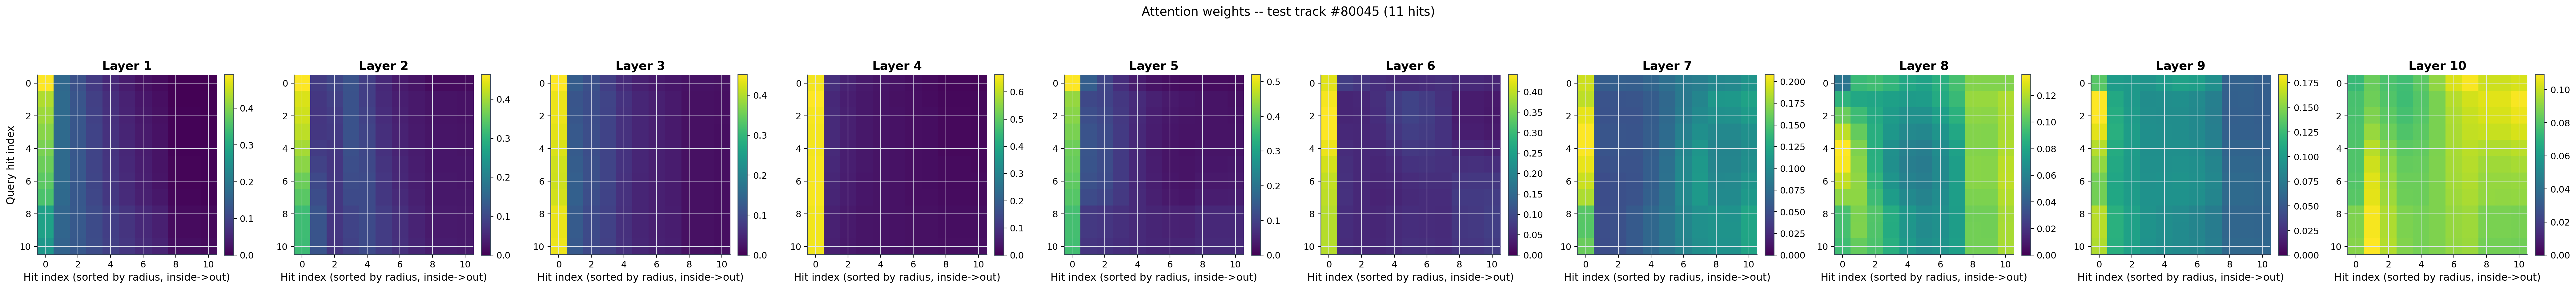

**attention_vs_radius_track25388.png**

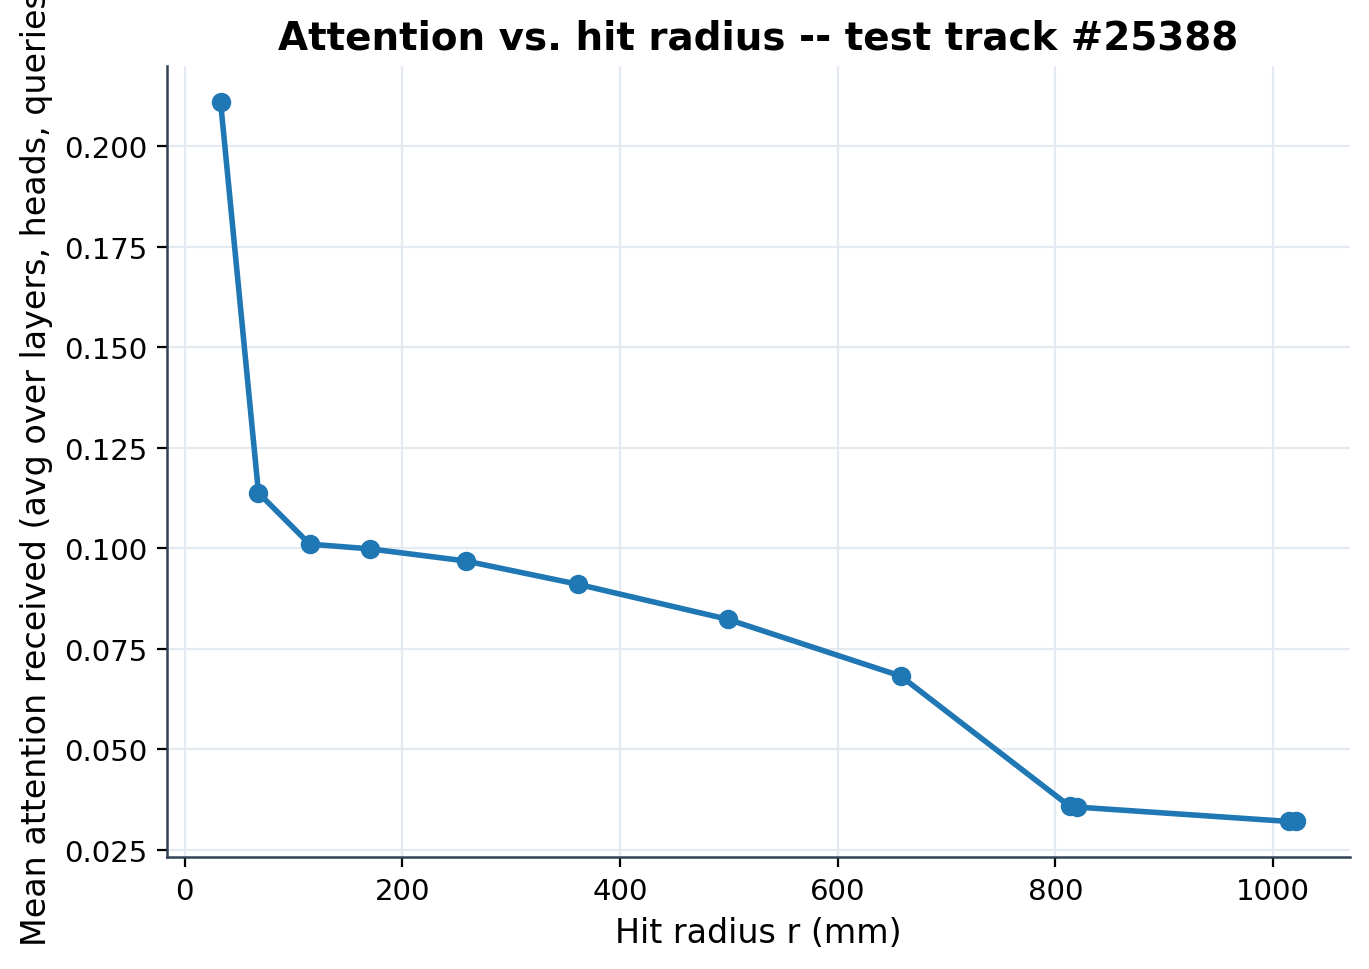

**attention_vs_radius_track48099.png**

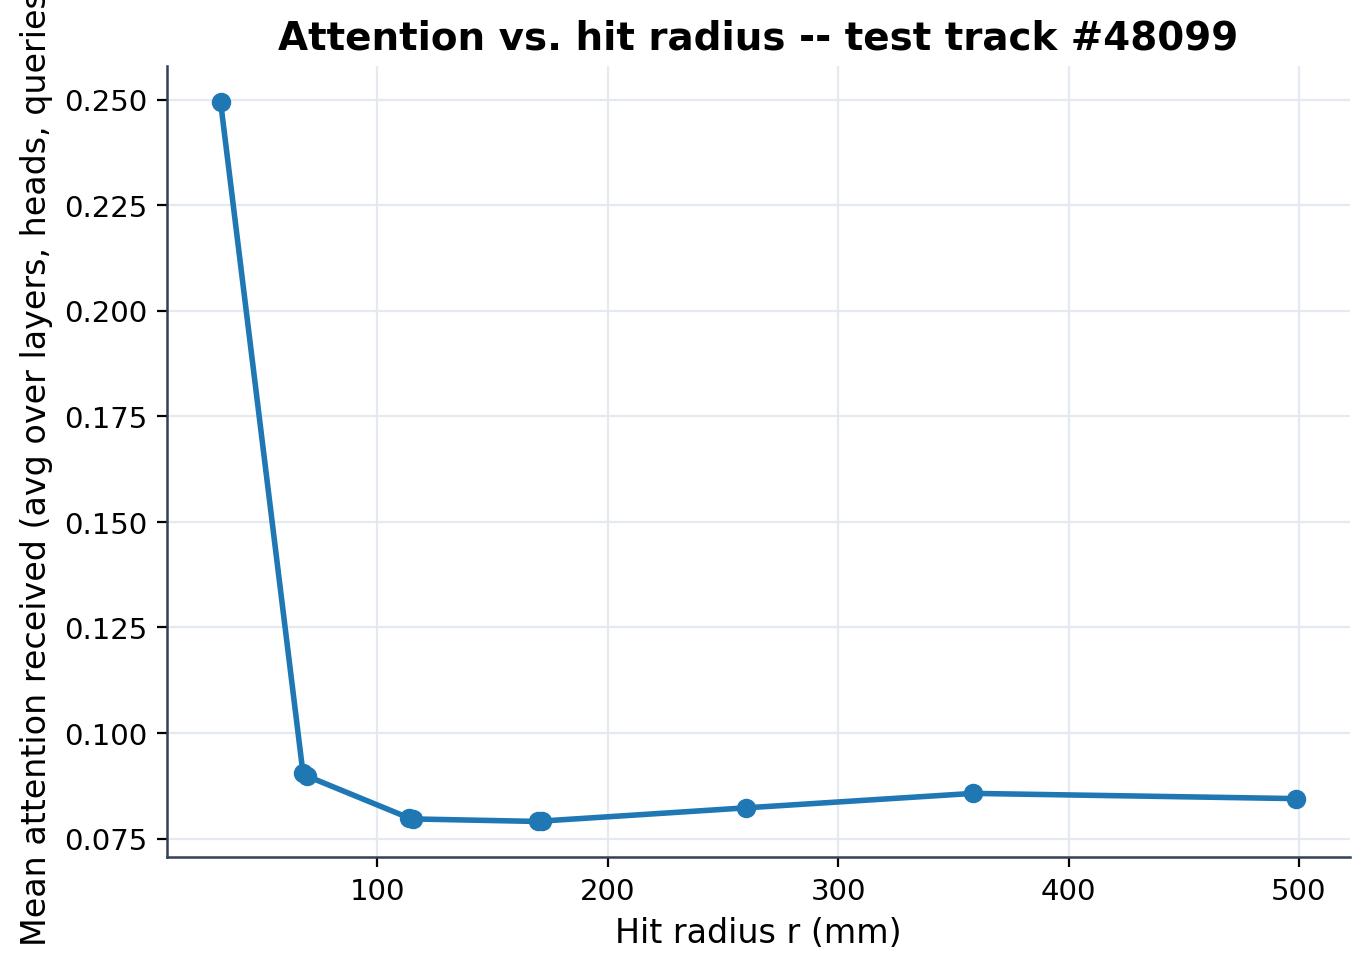

**attention_vs_radius_track59940.png**

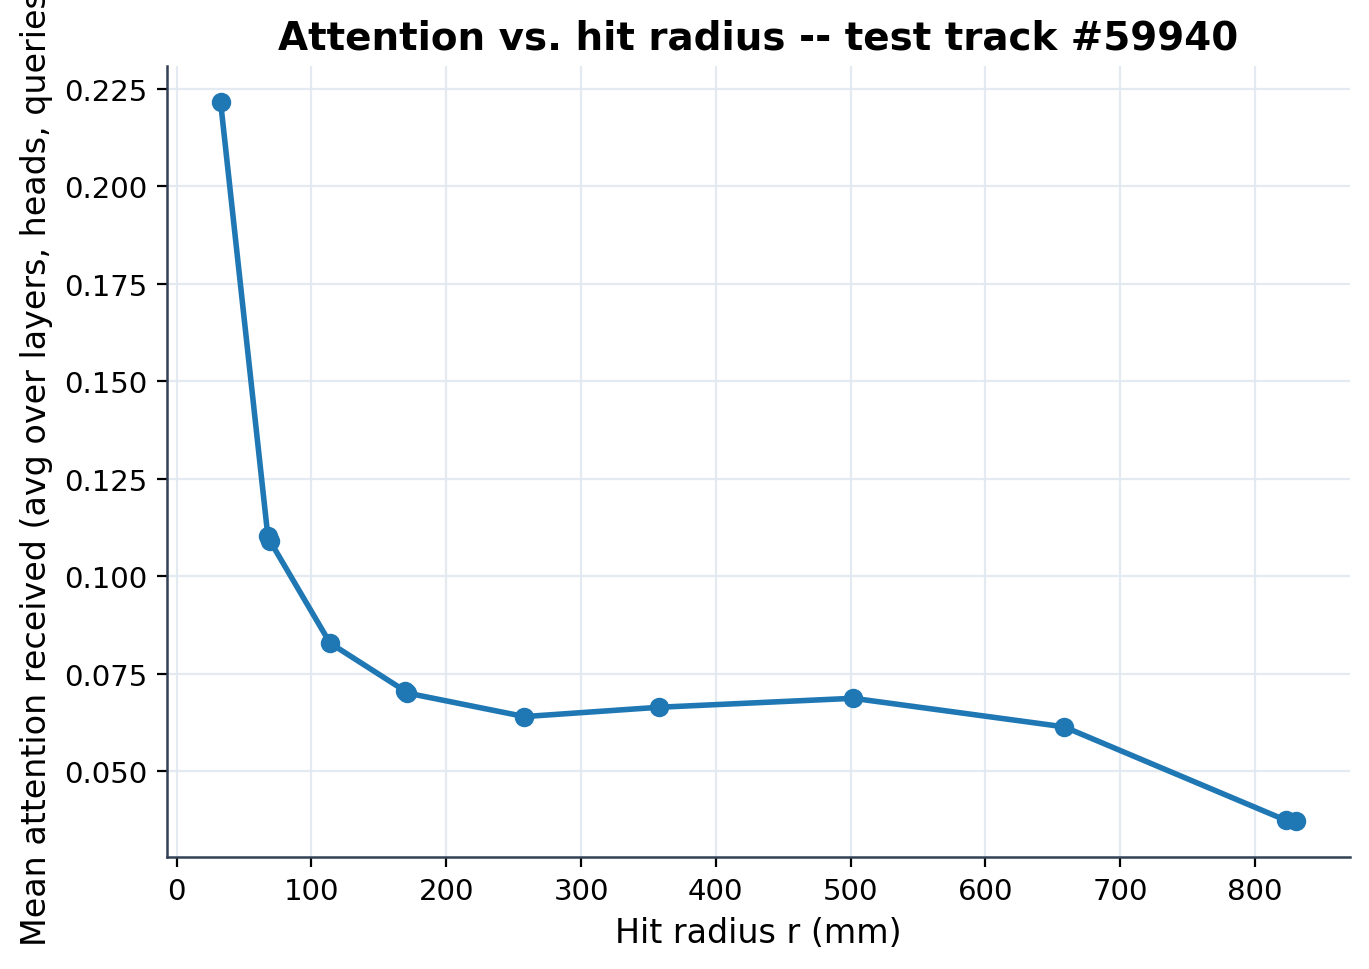

**attention_vs_radius_track80045.png**

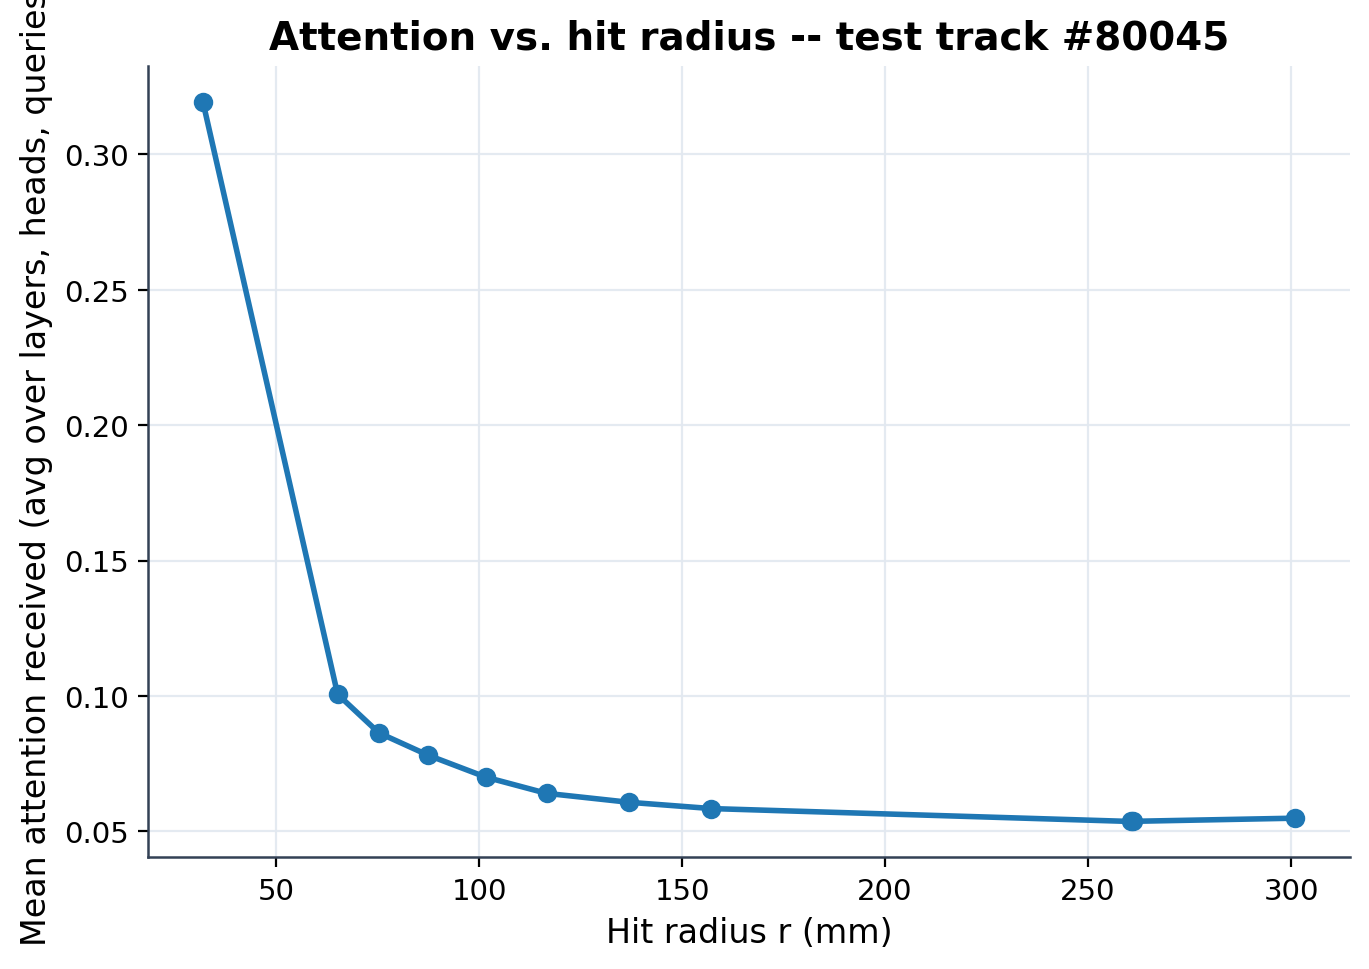

In [131]:
attn_dir = BEST / "attention_maps"

if not attn_dir.exists():
    print(f"No attention_maps/ folder for {BEST.name} -- run visualize_attention.py on the cluster first, then re-sync.")
else:
    for png in sorted(attn_dir.glob("*.png")):
        display(Markdown(f"**{png.name}**"))
        display(Image(filename=str(png), width=650))


### Combined attention maps (4 example tracks)

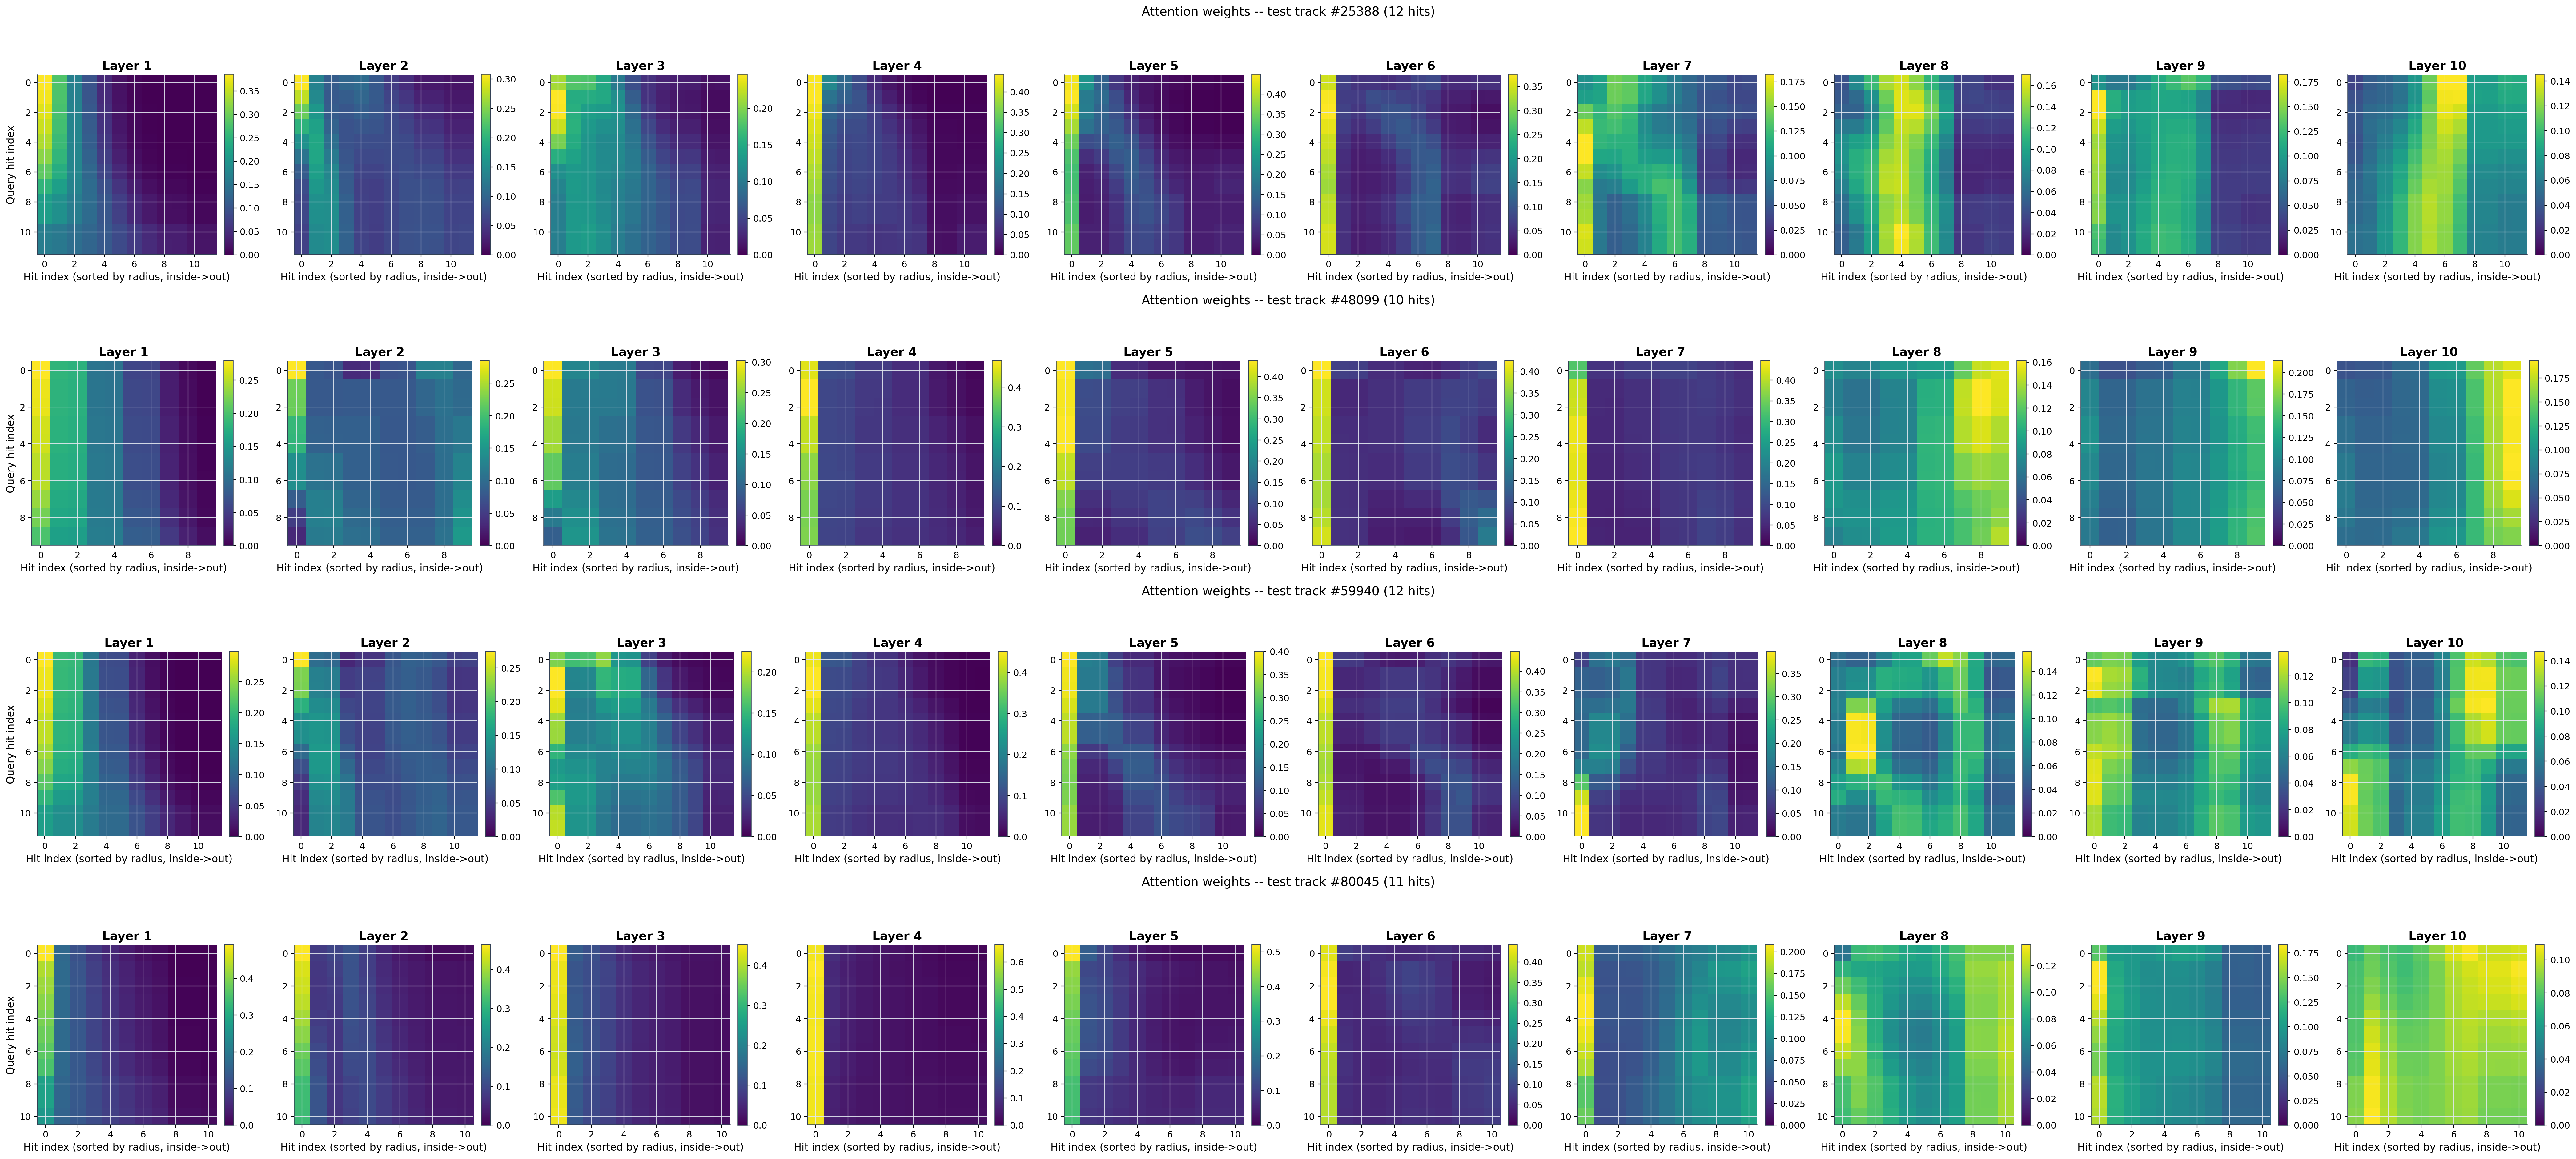

In [132]:
# Combine the four per-track attention maps into one 4x1 stacked figure
from PIL import Image as PILImage

track_ids = [25388, 48099, 59940, 80045]
imgs = [PILImage.open(attn_dir / f"attention_track{t}.png") for t in track_ids]

width = max(im.width for im in imgs)
total_height = sum(im.height for im in imgs)
combined = PILImage.new("RGB", (width, total_height), "white")

y = 0
for im in imgs:
    combined.paste(im, (0, y))
    y += im.height

out_path = attn_dir / "attention_combined.png"
combined.save(out_path)
display(Image(filename=str(out_path), width=1000))


# Study 2: Synthetic curriculum

## Precision sweep across curriculum stages

Adam-only vs. Adam+L-BFGS refinement vs. the least-squares baseline, for each of the 7 curriculum stages, aggregated across 3 seeds.

In [12]:
# Merged 3-seed results from the curriculum sweep (see
# merge_curriculum_seeds.py) -- per-seed rows and the aggregated
# mean/std-across-seeds summary.
CURRICULUM_DIR = BASE_DIR / "curriculum_sweep_merged"

curriculum_results = pd.read_csv(CURRICULUM_DIR / "sweep_summary_final.csv")
curriculum_summary = pd.read_csv(CURRICULUM_DIR / "sweep_summary_aggregated.csv")

print(f"Loaded {len(curriculum_results)} per-seed rows, "
      f"{curriculum_results['seed'].nunique()} seeds, from {CURRICULUM_DIR}")
curriculum_summary

Loaded 42 per-seed rows, 3 seeds, from /Users/meghnachoudhary/Macbook/UCL_MSc_ML/MSc Thesis/notebooks/ParamRegressionResults/Data/curriculum_sweep_merged


,stage,label,n_seeds,wall_time_min_mean,rmse_mean,rmse_std,mse_mean,mse_std,baseline_rmse_mean,baseline_mse_mean,ratio_mean,resolution_pct_mean,bias_pct_mean,beats_baseline_all
0,stage0_everything_fixed,adam_only,3,0.954494,0.000832,0.000415,8.075658e-07,6.207069e-07,5.388207e-08,2.903278e-15,2.781566e+08,0.036948,-0.161885,False
1,stage0_everything_fixed,adam_plus_bfgs,3,0.029905,0.000116,0.000030,1.408644e-08,7.128301e-09,5.388207e-08,2.903278e-15,4.851910e+06,0.021287,-0.000135,False
2,stage0b_pt_only,adam_only,3,3.149006,0.001115,0.000428,1.365064e-06,9.876407e-07,3.554388e-08,1.263367e-15,1.080497e+09,0.390979,-0.126815,False
3,stage0b_pt_only,adam_plus_bfgs,3,0.343426,0.000692,0.000013,4.785884e-07,1.747446e-08,3.554388e-08,1.263367e-15,3.788197e+08,0.230204,-0.007882,False
4,stage1_charge_only,adam_only,3,4.950230,0.000298,0.000215,1.196200e-07,1.543768e-07,5.362762e-08,2.875922e-15,4.159363e+07,0.060488,-0.003612,False
5,stage1_charge_only,adam_plus_bfgs,3,0.015729,0.000194,0.000041,3.865120e-08,1.614669e-08,5.362762e-08,2.875922e-15,1.343959e+07,0.033754,0.000064,False
6,stage2_varying_momentum,adam_only,3,6.249629,0.001757,0.000210,3.115351e-06,7.594389e-07,3.639576e-08,1.324651e-15,2.351827e+09,0.652938,0.003116,False
7,stage2_varying_momentum,adam_plus_bfgs,3,1.046298,0.000833,0.000014,6.938741e-07,2.282554e-08,3.639576e-08,1.324651e-15,5.238164e+08,0.227423,0.000836,False
8,stage3_vertex_offset,adam_only,3,6.188223,0.002227,0.000587,5.188976e-06,2.812580e-06,3.692663e-08,1.363576e-15,3.805418e+09,0.494612,-0.004333,False
9,stage3_vertex_offset,adam_plus_bfgs,3,0.843167,0.002995,0.000571,9.187668e-06,3.583798e-06,3.692663e-08,1.363576e-15,6.737922e+09,0.218639,-0.002258,False


### Precision vs. curriculum stage -- errorbar and band versions

Same data, two styles: errorbar matches the plotting convention used throughout Study 1; the band version shows the same mean +/- std as a filled region instead.

In [13]:
# !pip install pymupdf

In [14]:
# IFrame doesn't reliably render local PDFs in every notebook front-end
# (e.g. VS Code's webview blocks local file:// content). Rasterize the
# first page instead and show it as a normal image.
import fitz  # pip install pymupdf

def show_pdf(path, dpi=150):
    page = fitz.open(str(path))[0]
    display(Image(data=page.get_pixmap(dpi=dpi).tobytes("png")))

RMSE vs. curriculum stage: Adam / Adam+L-BFGS / least-squares baseline (errorbar)


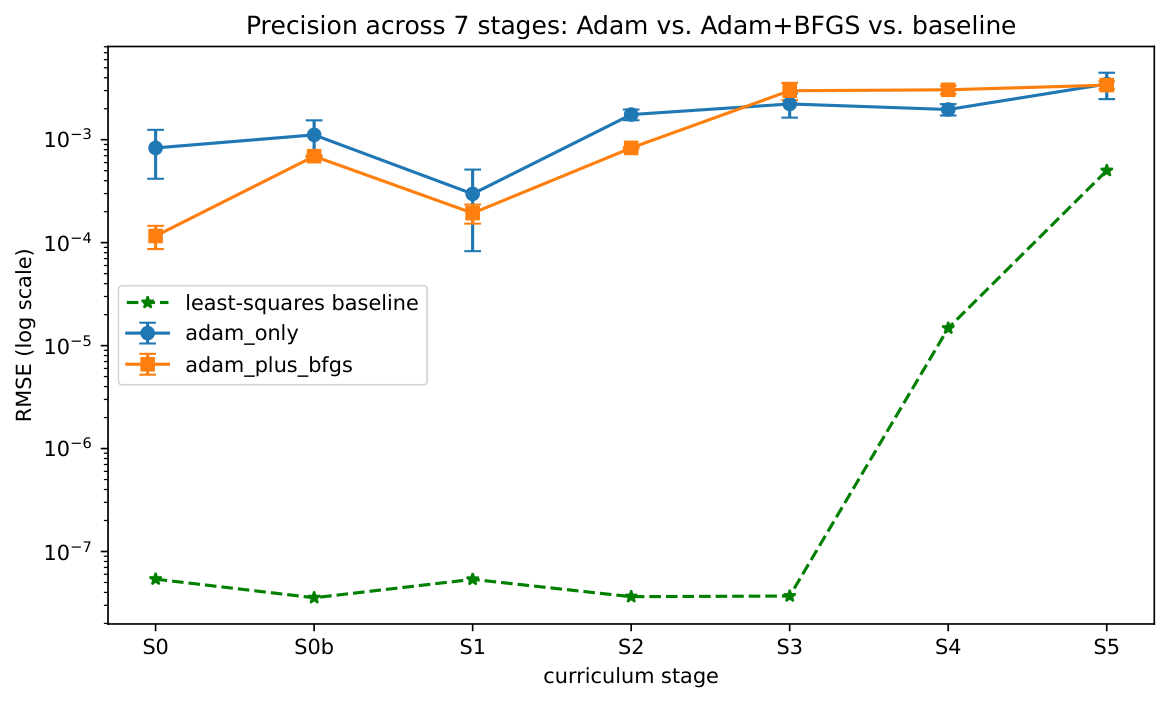

In [15]:
print("RMSE vs. curriculum stage: Adam / Adam+L-BFGS / least-squares baseline (errorbar)")
show_pdf(CURRICULUM_DIR / "full_sweep_summary.pdf")

RMSE vs. curriculum stage: mean +/- std across seeds (filled band)


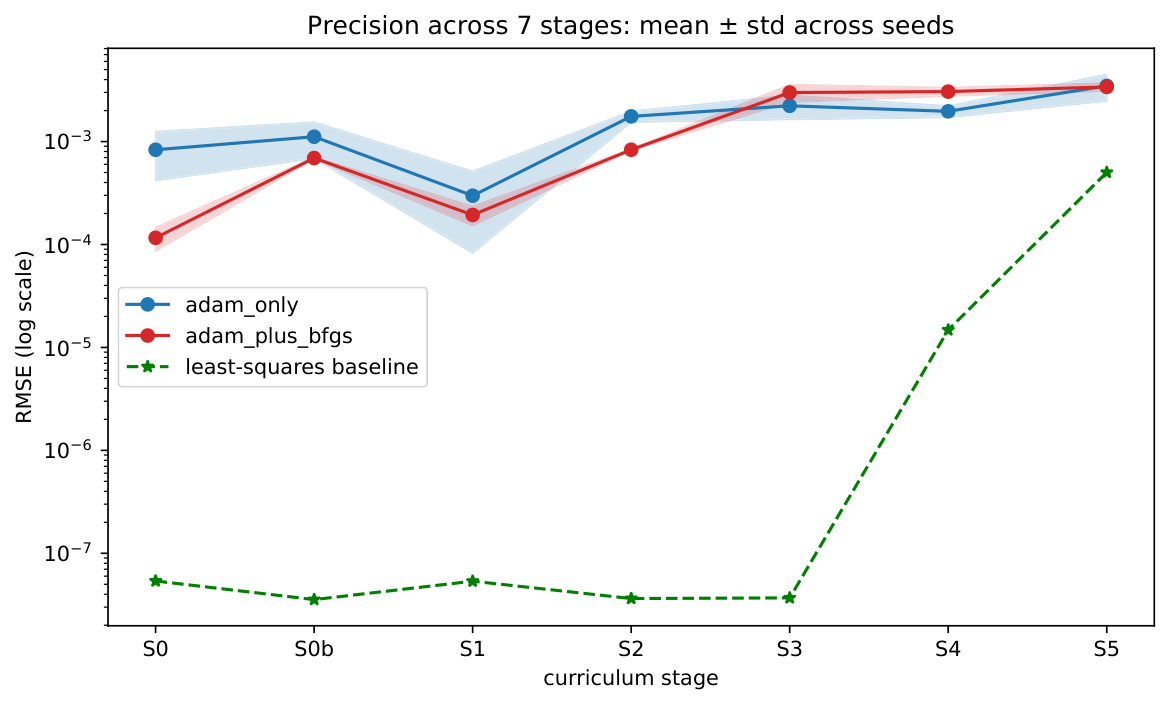

In [16]:
print("RMSE vs. curriculum stage: mean +/- std across seeds (filled band)")
show_pdf(CURRICULUM_DIR / "full_sweep_summary_band.pdf")

### Adam-to-L-BFGS loss curves, per stage

Adam (blue) -> L-BFGS (red) loss curves, one panel per curriculum stage (seed 0)


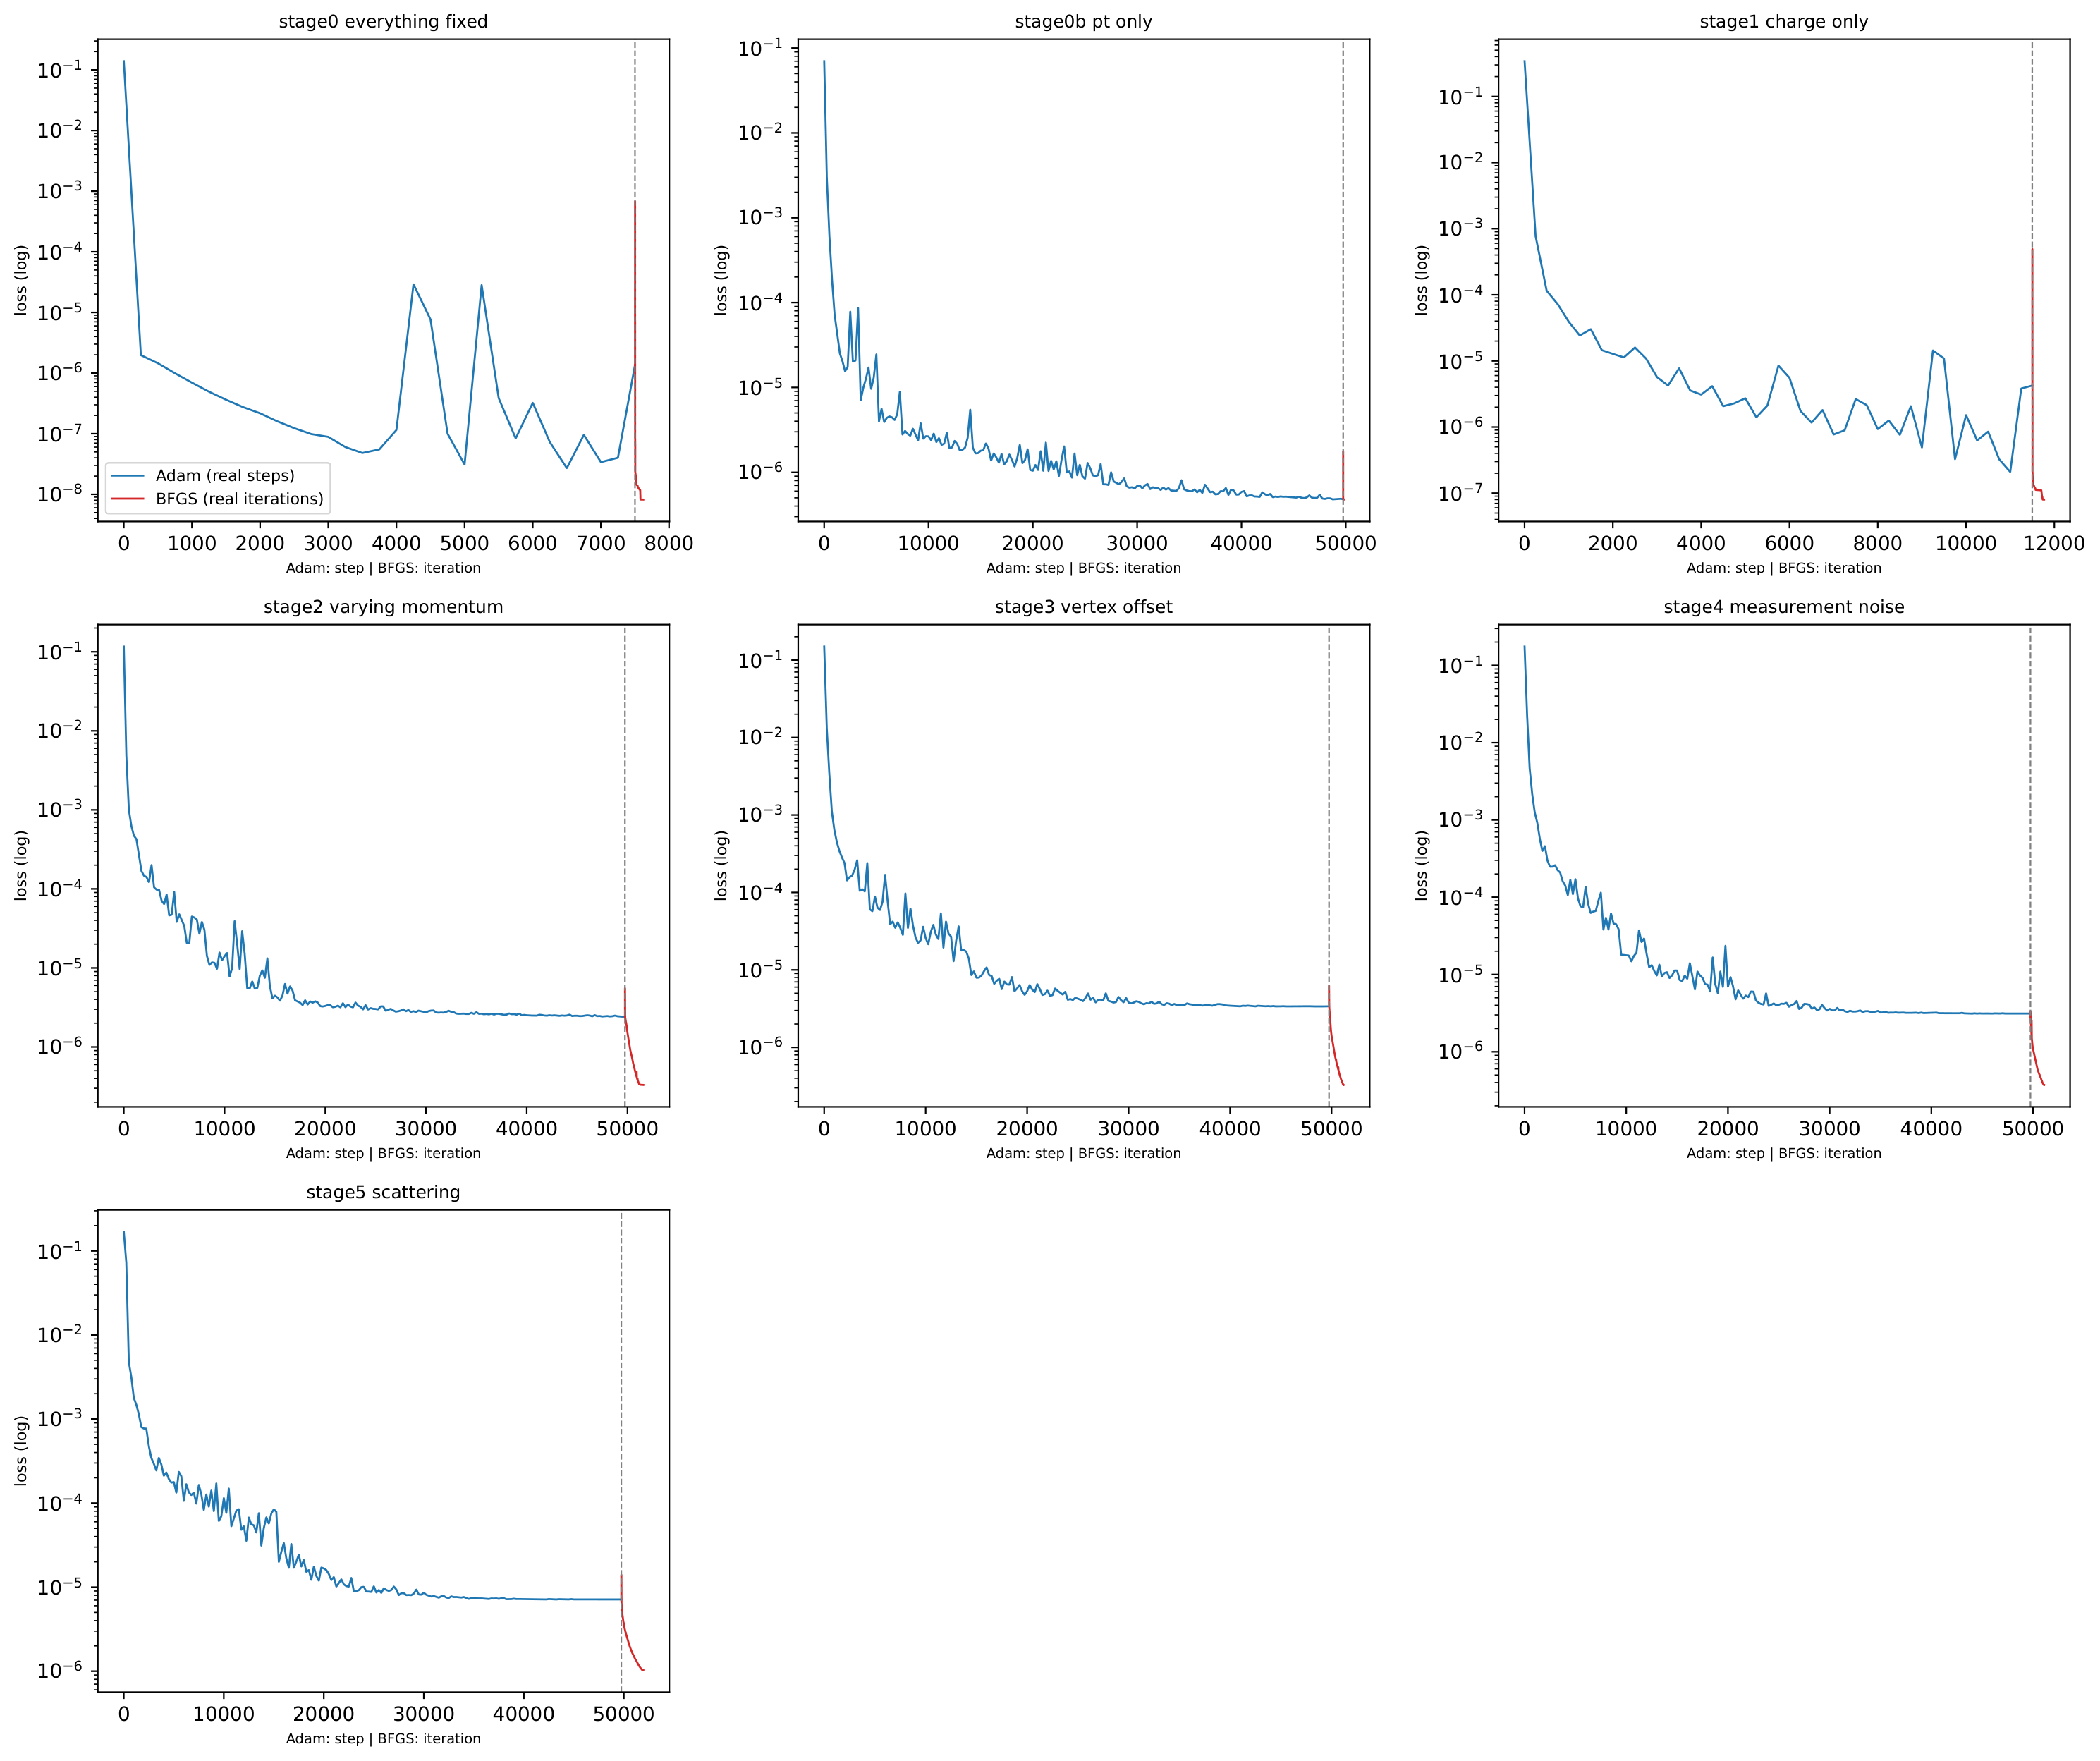

In [17]:
print("Adam (blue) -> L-BFGS (red) loss curves, one panel per curriculum stage (seed 0)")
show_pdf(BASE_DIR / "curriculum_sweep_seed2" / "kink_plots_all_stages.pdf", dpi=200)

### Residual distributions after refinement, per stage

Relative residual distributions after refinement, one panel per curriculum stage (seed 0)


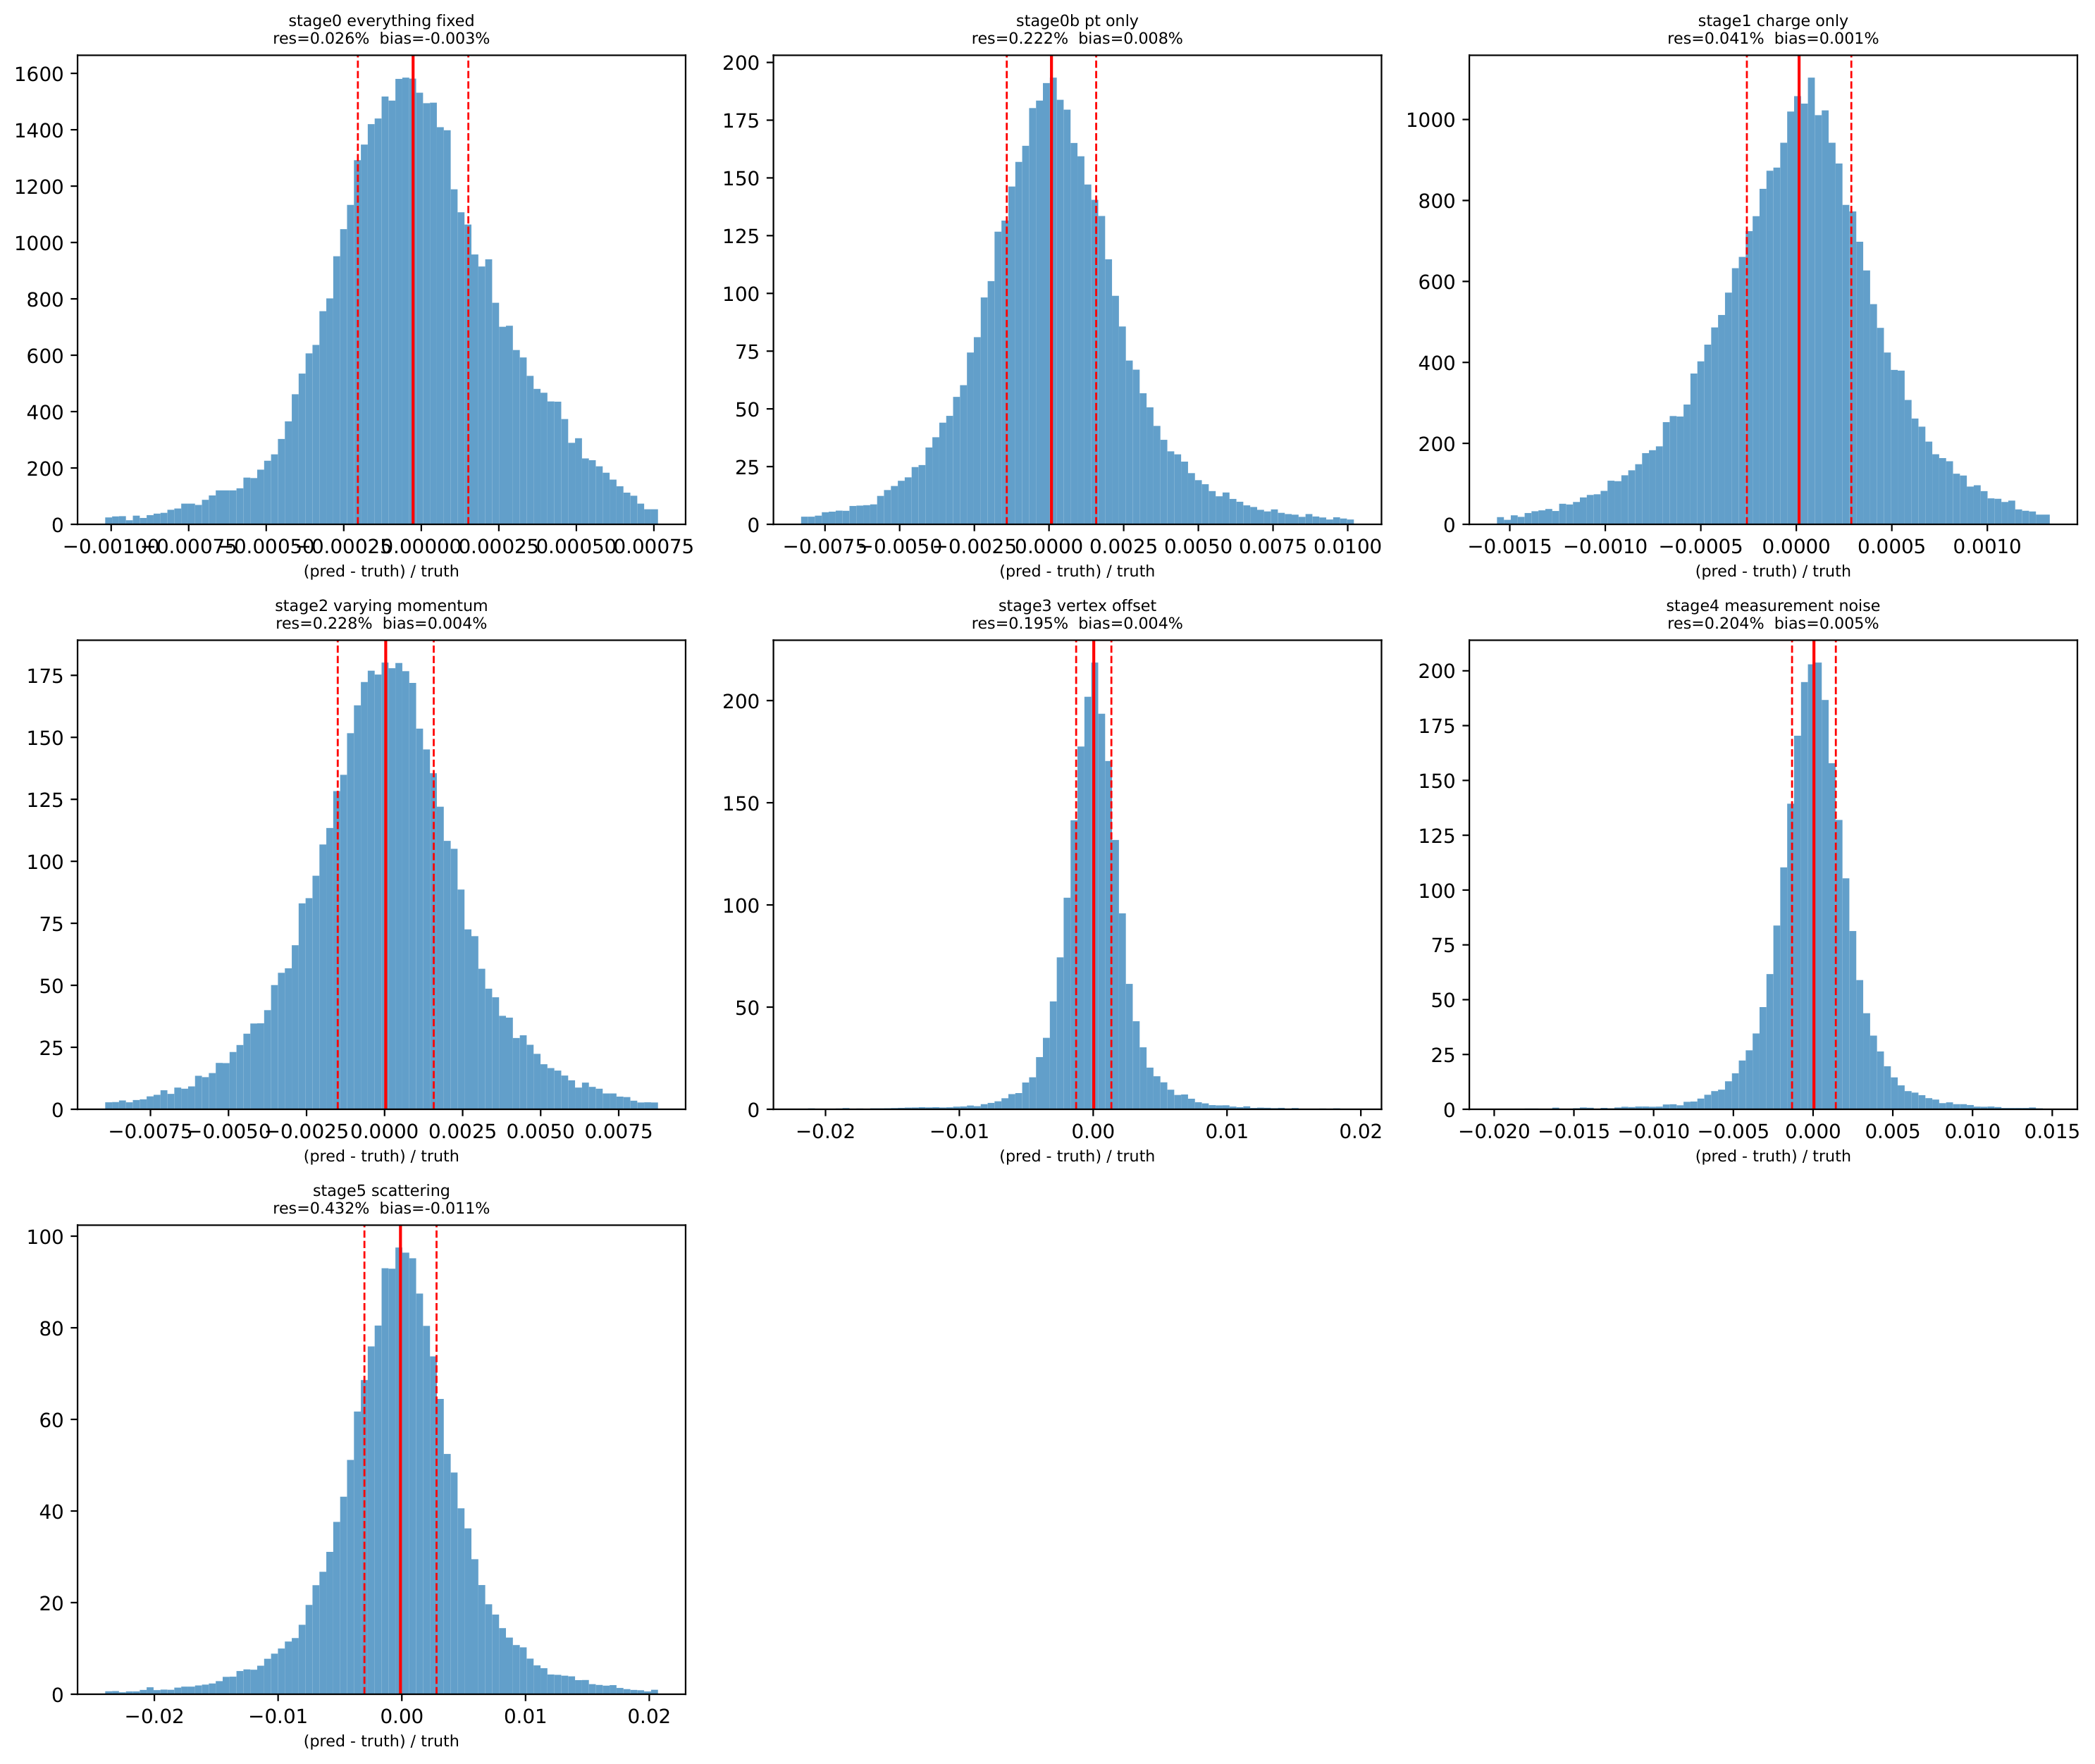

In [18]:
print("Relative residual distributions after refinement, one panel per curriculum stage (seed 0)")
show_pdf(BASE_DIR / "curriculum_sweep_seed0" / "residual_distributions_all_stages.pdf", dpi=200)